In [14]:
import numpy as np
import pandas as pd
from astropy.table import Table
import matplotlib.pyplot as plt

LSdata_df = pd.read_csv('Compilation2026_main.csv',comment='#',index_col=False, dtype={'GEHR_id': str})
LS_tab = Table.from_pandas(LSdata_df)
gehr_data = LS_tab[LS_tab['origin_id']==0.0]

logsigma_true = np.random.choice(
    gehr_data["log_sigma"],
    size=100000,
    replace=True
)

In [17]:
eps = np.random.normal(
    0.0,
    0.2,
    size=100000
)

logL_true = (
    33.25
    + 5.02 * logsigma_true
    + eps
)



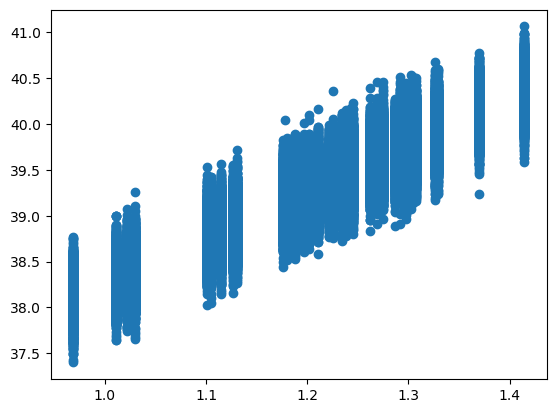

In [18]:
plt.scatter(logsigma_true,logL_true)

In [19]:
import numpy as np
import pandas as pd


def simulate_GEHR_host(
    mu,
    N,
    alpha,
    beta,
    sigma_int,
    logsigma_reference
):

    # -------------------------------
    # 1. Sigma latente
    # -------------------------------

    logsigma_true = np.random.choice(
        logsigma_reference,
        size=N,
        replace=True
    )

    sigma_true = 10**logsigma_true


    # -------------------------------
    # 2. Scatter intrínseco
    # -------------------------------

    eps_int = np.random.normal(
        0.0,
        sigma_int,
        size=N
    )


    # -------------------------------
    # 3. L(Hbeta)
    # -------------------------------

    logL_true = (
        alpha
        + beta * logsigma_true
        + eps_int
    )


    # -------------------------------
    # 4. F(Hbeta)
    # log F = log L - 0.4 mu - 40.079
    # -------------------------------

    logF_true = (
        logL_true
        - 0.4 * mu
        - 40.079
    )

    flux_true = 10**logF_true


    return pd.DataFrame({
        "mu": mu,
        "sigma_kms": sigma_true,
        "LogSigma": logsigma_true,
        "LogL_Hb": logL_true,
        "LogFlux_Hb": logF_true,
        "Flux_Hb": flux_true
    })

In [36]:
mock_Galaxy = simulate_GEHR_host(
    mu=28.22,
    N=100000,
    alpha=33.25,
    beta=5.02,
    sigma_int=0.2,
    logsigma_reference=gehr_data["log_sigma"]
)

filas_aleatorias = mock_Galaxy.sample(n=1)
filas_aleatorias

# 29.15 5.M101
# 29.15 5.M101
# 24.58 3.M33
# 29.80 7.NGC0925
# 27.63 8.NGC2366
# 27.49 9.NGC2403
# 30.35 10.NGC2541
# 30.65 12.NGC3319
# 29.8  15.NGC4258
# 28.22 16.NGC4395

,mu,sigma_kms,LogSigma,LogL_Hb,LogFlux_Hb,Flux_Hb
95746,28.22,12.738339,1.105113,38.86188,-12.50512,3.125219e-13


In [39]:
GEHR_NAMES = ["5.M101" , "5.M101" , "3.M33" , "7.NGC0925" , "8.NGC2366" , "9.NGC2403" , "10.NGC2541" , "12.NGC3319" , "15.NGC4258" , "16.NGC4395" , "18.NGC1073" , "19.NGC2500" , "21.M96" , "22.NGC3370" , "23.M66" , "24.NGC4414" , "28.NGC4725" , "29.UGC08091" , "30.NGC5204" , "31.UGC09128" , "1.IC0010" , "1.IC0010" , "1.IC0010" , "3.M33" , "3.M33" , "3.M33" , "4.M81" , "4.M81" , "5.M101" , "5.M101" , "5.M101" , "7.NGC0925" , "7.NGC0925" , "8.NGC2366" , "9.NGC2403" , "9.NGC2403" , "10.NGC2541" , "10.NGC2541" , "10.NGC2541" , "11.NGC3198" , "11.NGC3198" , "11.NGC3198" , "12.NGC3319" , "12.NGC3319" , "12.NGC3319" , "15.NGC4258" , "15.NGC4258" , "15.NGC4258" , "16.NGC4395" , "16.NGC4395" , "2.IC2574" , "2.IC2574" , "13.NGC4214" , "14.NGC4236" , "17.NGC6822" , "17.NGC6822" , "18.NGC1073" , "18.NGC1073" , "19.NGC2500" , "19.NGC2500" , "21.M96" , "21.M96" , "22.NGC3370" , "23.M66" , "24.NGC4414" , "24.NGC4414" , "25.NGC4496" , "26.NGC4535" , "26.NGC4535" , "27.NGC4536" , "28.NGC4725" , "29.UGC08091" , "30.NGC5204" , "31.UGC09128" , "31.UGC09128" , "32.NGC5584" , "32.NGC5584" , "32.NGC5584" , "33.NGC7331" , "33.NGC7331"]

GEHR_muS = [29.15 , 29.15 , 24.58 , 29.8 , 27.63 , 27.49 , 30.35 , 30.65 , 29.8 , 28.22 , 30.26 , 30.18 , 30.34 , 32.123 , 30.5 , 31.27 , 30.65 , 26.65 , 28.4 , 26.76 , 24.22 , 24.22 , 24.22 , 24.58 , 24.58 , 24.58 , 27.8 , 27.8 , 29.15 , 29.15 , 29.15 , 29.8 , 29.8 , 27.63 , 27.49 , 27.49 , 30.35 , 30.35 , 30.35 , 30.75 , 30.75 , 30.75 , 30.65 , 30.65 , 30.65 , 29.37 , 29.37 , 29.37 , 28.22 , 28.22 , 27.95 , 27.95 , 27.34 , 28.22 , 23.43 , 23.43 , 30.26 , 30.26 , 30.18 , 30.18 , 30.34 , 30.34 , 32.12 , 30.5 , 31.65 , 31.65 , 31.18 , 31.25 , 31.25 , 30.83 , 30.65 , 26.65 , 28.4 , 26.76 , 26.76 , 31.775 , 31.775 , 31.775 , 30.89 , 30.89]

In [40]:
for g in range(len(GEHR_NAMES)):

    mock_Galaxy = simulate_GEHR_host(
        mu=GEHR_muS[g],
        N=100000,
        alpha=33.25,
        beta=5.02,
        sigma_int=0.2,
        logsigma_reference=gehr_data["log_sigma"]
    )

    sample = mock_Galaxy.sample(n=1)

    print(f"{GEHR_muS[g]}	{0.0}	{sample["LogSigma"].iloc[0]}	{0.0}	{sample["LogFlux_Hb"].iloc[0]}	{0.0}	{0.0}	{GEHR_NAMES[g]}")

    

29.15	0.0	1.2917336	0.0	-11.900186673087074	0.0	0.0	5.M101
29.15	0.0	1.2344576	0.0	-12.304213852715531	0.0	0.0	5.M101
24.58	0.0	1.1308849	0.0	-10.540120534068699	0.0	0.0	3.M33
29.8	0.0	1.1144041	0.0	-13.54489762083604	0.0	0.0	7.NGC0925
27.63	0.0	1.2455455	0.0	-11.581753696890317	0.0	0.0	8.NGC2366
27.49	0.0	1.3043677	0.0	-11.385987647160952	0.0	0.0	9.NGC2403
30.35	0.0	1.22127	0.0	-12.987935476090811	0.0	0.0	10.NGC2541
30.65	0.0	1.2455455	0.0	-12.878566606651994	0.0	0.0	12.NGC3319
29.8	0.0	1.1262528	0.0	-13.501814823640466	0.0	0.0	15.NGC4258
28.22	0.0	1.0219418	0.0	-12.908224490850753	0.0	0.0	16.NGC4395
30.26	0.0	1.1880504	0.0	-13.024203023528337	0.0	0.0	18.NGC1073
30.18	0.0	1.23822	0.0	-12.887854898528175	0.0	0.0	19.NGC2500
30.34	0.0	1.3291017	0.0	-12.101408910163222	0.0	0.0	21.M96
32.123	0.0	1.1262528	0.0	-13.88005827999326	0.0	0.0	22.NGC3370
30.5	0.0	1.1803352	0.0	-13.162023470648016	0.0	0.0	23.M66
31.27	0.0	1.2958639	0.0	-13.160060898164176	0.0	0.0	24.NGC4414
30.65	0.0	1.1262528	0.0	

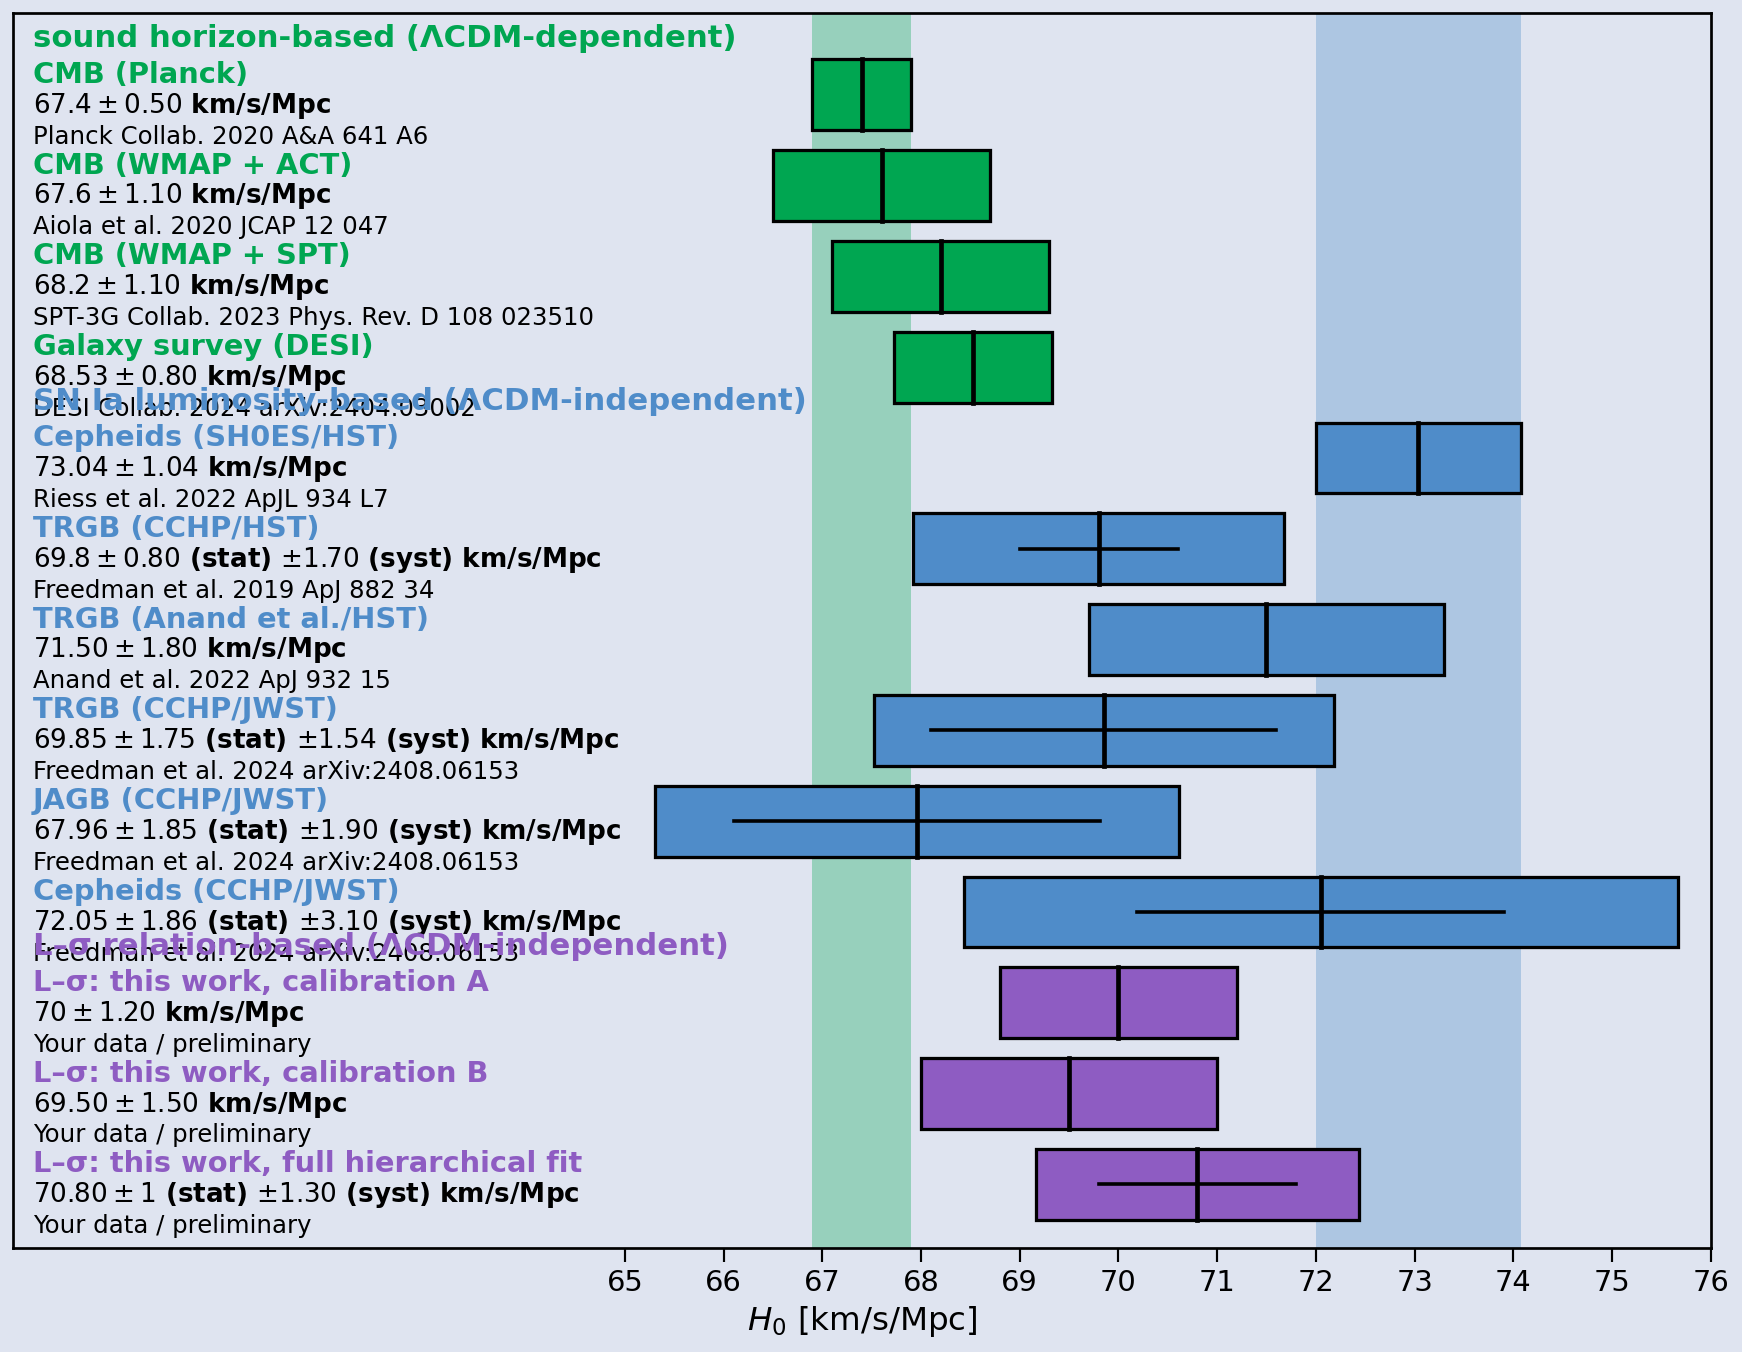

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ============================================================
# Datos
# ============================================================

data = [
    # group, label, value, err_stat, err_syst, reference, color_type
    ("sound horizon-based (ΛCDM-dependent)",
     "CMB (Planck)",
     67.4, 0.5, None,
     "Planck Collab. 2020 A&A 641 A6",
     "green"),

    ("",
     "CMB (WMAP + ACT)",
     67.6, 1.1, None,
     "Aiola et al. 2020 JCAP 12 047",
     "green"),

    ("",
     "CMB (WMAP + SPT)",
     68.2, 1.1, None,
     "SPT-3G Collab. 2023 Phys. Rev. D 108 023510",
     "green"),

    ("",
     "Galaxy survey (DESI)",
     68.53, 0.80, None,
     "DESI Collab. 2024 arXiv:2404.03002",
     "green"),

    ("SN Ia luminosity-based (ΛCDM-independent)",
     "Cepheids (SH0ES/HST)",
     73.04, 1.04, None,
     "Riess et al. 2022 ApJL 934 L7",
     "blue"),

    ("",
     "TRGB (CCHP/HST)",
     69.8, 0.8, 1.7,
     "Freedman et al. 2019 ApJ 882 34",
     "blue"),

    ("",
     "TRGB (Anand et al./HST)",
     71.5, 1.8, None,
     "Anand et al. 2022 ApJ 932 15",
     "blue"),

    ("",
     "TRGB (CCHP/JWST)",
     69.85, 1.75, 1.54,
     "Freedman et al. 2024 arXiv:2408.06153",
     "blue"),

    ("",
     "JAGB (CCHP/JWST)",
     67.96, 1.85, 1.90,
     "Freedman et al. 2024 arXiv:2408.06153",
     "blue"),

    ("",
     "Cepheids (CCHP/JWST)",
     72.05, 1.86, 3.10,
     "Freedman et al. 2024 arXiv:2408.06153",
     "blue"),

    # ========================================================
    # Tres espacios para tus resultados L-sigma
    # Cambia value, err_stat, err_syst y reference cuando los tengas
    # ========================================================
    ("L–σ relation-based (ΛCDM-independent)",
     "L–σ: this work, calibration A",
     70.0, 1.2, None,
     "Your data / preliminary",
     "purple"),

    ("",
     "L–σ: this work, calibration B",
     69.5, 1.5, None,
     "Your data / preliminary",
     "purple"),

    ("",
     "L–σ: this work, full hierarchical fit",
     70.8, 1.0, 1.3,
     "Your data / preliminary",
     "purple"),
]


# ============================================================
# Estilo
# ============================================================

bg = "#dfe4f0"
green = "#00a651"
blue = "#4f8cc9"
purple = "#8e5cc2"

colors = {
    "green": green,
    "blue": blue,
    "purple": purple,
}

text_colors = {
    "green": green,
    "blue": blue,
    "purple": purple,
}

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=(13.5, 10.5), dpi=130)
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)

N = len(data)
y_positions = np.arange(N)[::-1]

ax.set_xlim(58.8, 76.0)
ax.set_ylim(-0.7, N - 0.1)

# Bandas de referencia
planck_mean, planck_err = 67.4, 0.5
shoes_mean, shoes_err = 73.04, 1.04

ax.axvspan(
    planck_mean - planck_err,
    planck_mean + planck_err,
    color=green,
    alpha=0.32,
    lw=0,
    zorder=0
)

ax.axvspan(
    shoes_mean - shoes_err,
    shoes_mean + shoes_err,
    color=blue,
    alpha=0.34,
    lw=0,
    zorder=0
)

# Región de texto
x_text = 59.0

box_height = 0.78

for i, row in enumerate(data):
    group, label, value, err_stat, err_syst, reference, color_key = row
    y = y_positions[i]
    c = colors[color_key]

    # Error total: si hay sistemático, se combina en cuadratura
    if err_syst is None:
        err_total = err_stat
    else:
        err_total = np.sqrt(err_stat**2 + err_syst**2)

    # Caja de incertidumbre total
    rect = Rectangle(
        (value - err_total, y - box_height / 2),
        2 * err_total,
        box_height,
        facecolor=c,
        edgecolor="black",
        lw=1.8,
        zorder=3
    )
    ax.add_patch(rect)

    # Línea vertical central
    ax.plot(
        [value, value],
        [y - box_height / 2, y + box_height / 2],
        color="black",
        lw=2.6,
        zorder=4
    )

    # Si hay error estadístico y sistemático, mostrar barra estadística interna
    if err_syst is not None:
        ax.plot(
            [value - err_stat, value + err_stat],
            [y, y],
            color="black",
            lw=2.0,
            zorder=5
        )

    # Encabezado de grupo
    if group:
        ax.text(
            x_text, y + 0.62,
            group,
            ha="left",
            va="center",
            fontsize=17,
            fontweight="bold",
            color=text_colors[color_key]
        )

    # Texto de medición
    ax.text(
        x_text, y + 0.22,
        label,
        ha="left",
        va="center",
        fontsize=16,
        fontweight="bold",
        color=text_colors[color_key]
    )

    # Formato del valor
    if err_syst is None:
        value_text = rf"${value:.2f} \pm {err_stat:.2f}$ km/s/Mpc"
    else:
        value_text = rf"${value:.2f} \pm {err_stat:.2f}$ (stat) $\pm {err_syst:.2f}$ (syst) km/s/Mpc"

    # Ajustes para que se parezca más al original
    value_text = value_text.replace(".00", "")
    value_text = value_text.replace("67.40", "67.4")
    value_text = value_text.replace("67.60", "67.6")
    value_text = value_text.replace("68.20", "68.2")
    value_text = value_text.replace("69.80", "69.8")

    ax.text(
        x_text,
        y - 0.12,
        value_text,
        ha="left",
        va="center",
        fontsize=14.5,
        fontweight="bold",
        color="black"
    )

    ax.text(
        x_text,
        y - 0.46,
        reference,
        ha="left",
        va="center",
        fontsize=13.5,
        color="black"
    )

# ============================================================
# Ejes
# ============================================================

ax.set_xlabel(r"$H_0$ [km/s/Mpc]", fontsize=18)
ax.set_yticks([])

ax.set_xticks(np.arange(65, 77, 1))
ax.tick_params(axis="x", labelsize=16, length=8, width=1.2)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color("black")

plt.tight_layout()

# Guardar
plt.savefig("H0_tension_Lsigma_comparison.png", dpi=300, bbox_inches="tight")
plt.savefig("H0_tension_Lsigma_comparison.pdf", bbox_inches="tight")

plt.show()

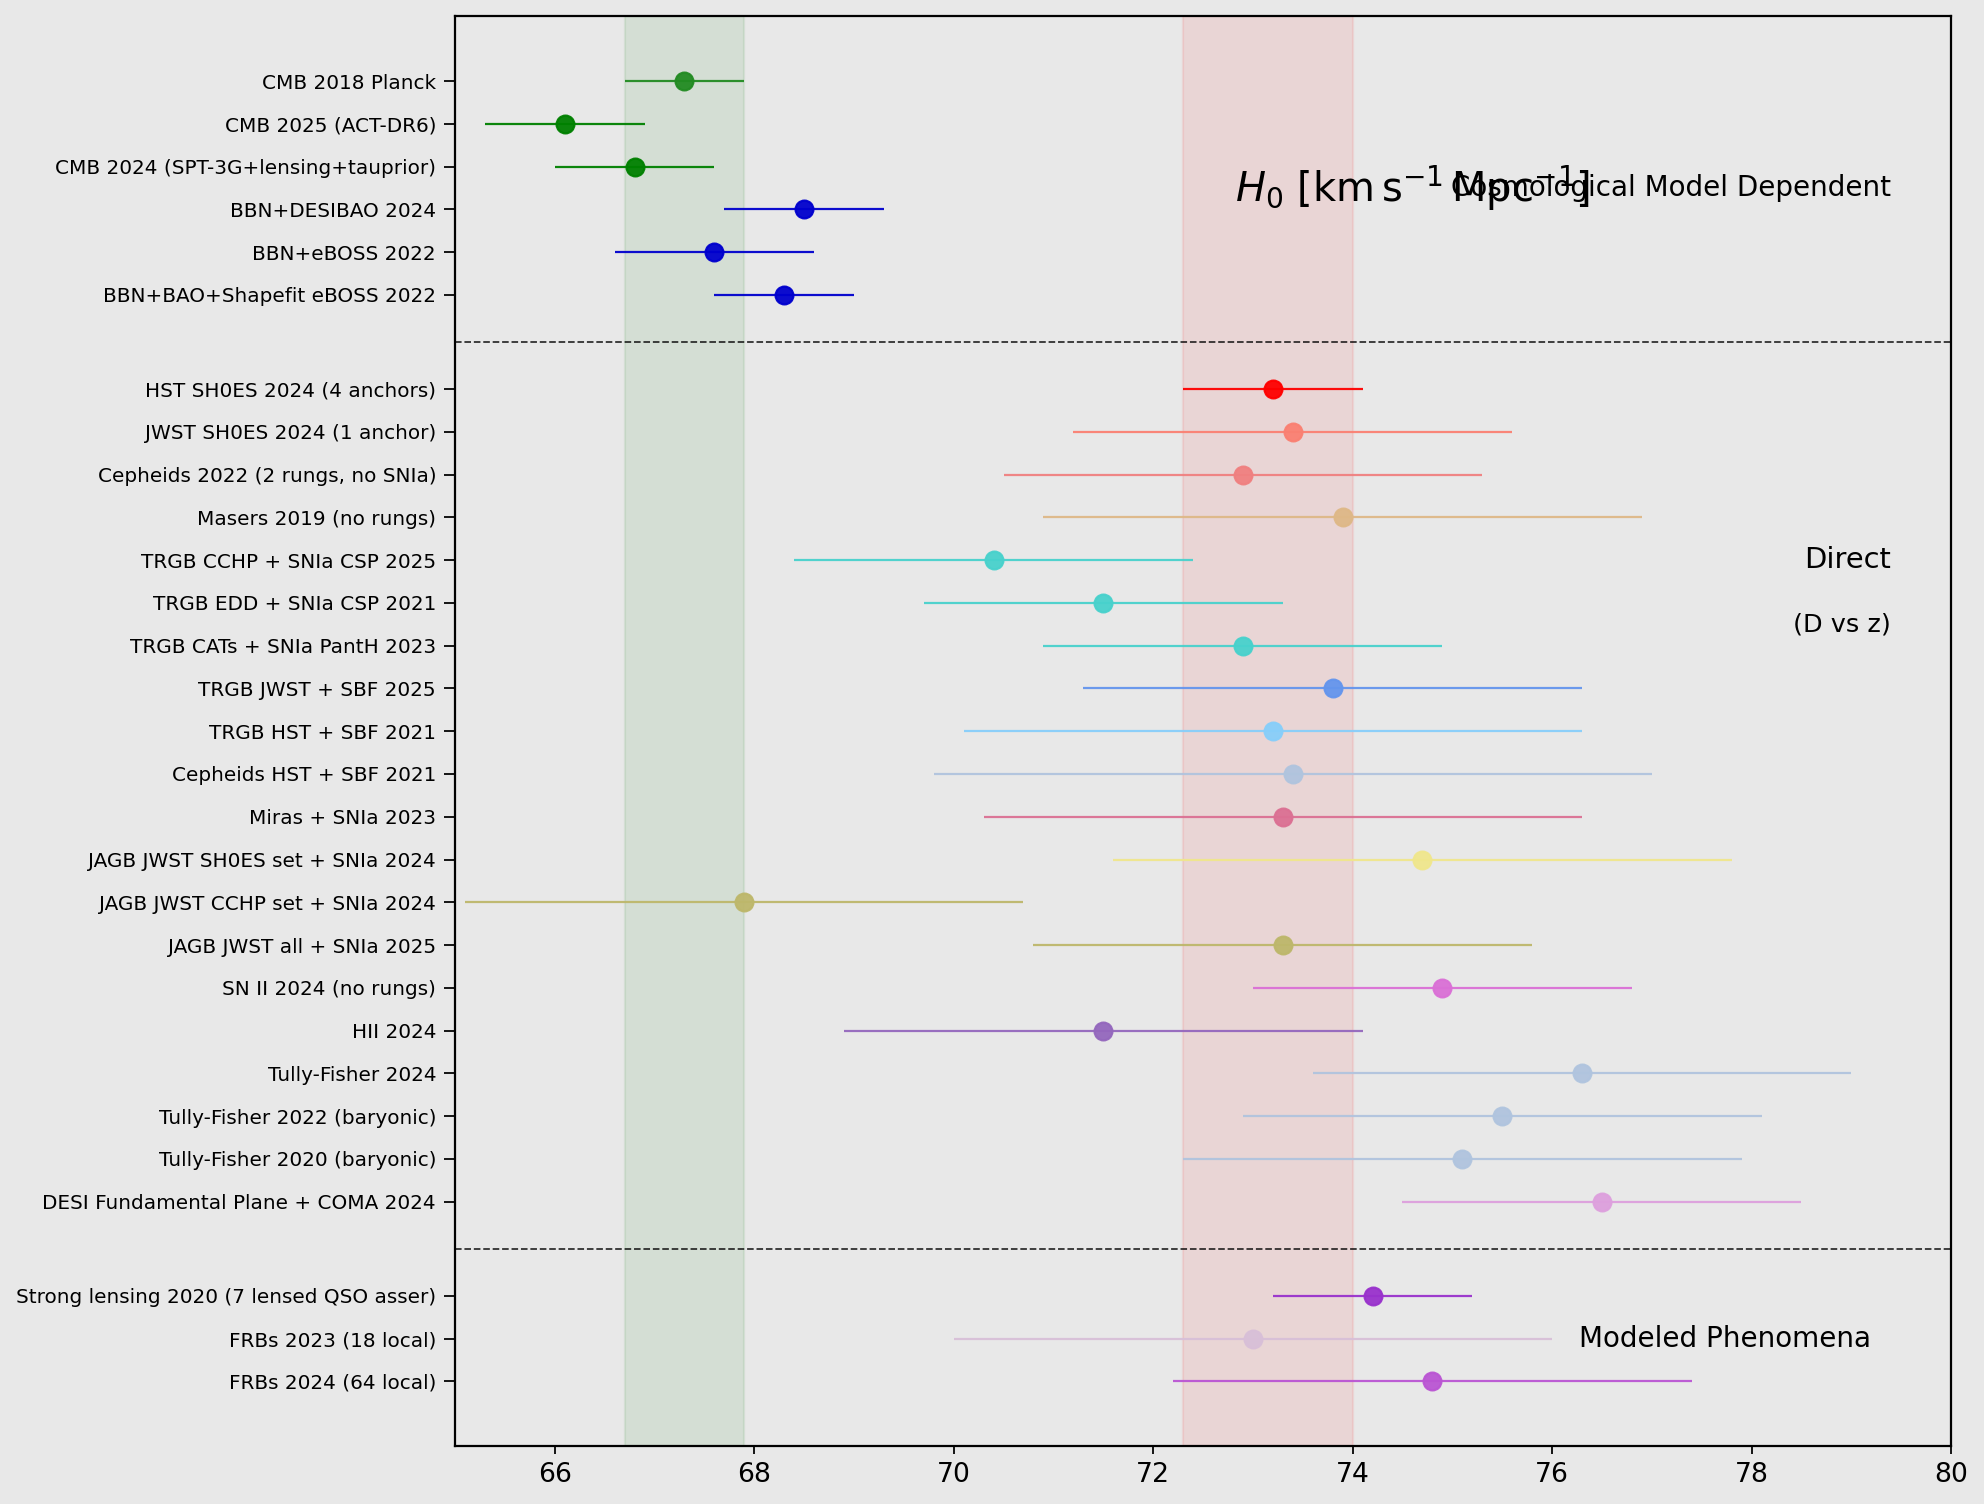

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Datos aproximados reconstruidos visualmente desde la imagen
# ============================================================

data = [
    # -------------------------------
    # Cosmological Model Dependent
    # -------------------------------
    {"group": "model", "label": "CMB 2018 Planck",                          "x": 67.3, "err": 0.6, "color": "forestgreen"},
    {"group": "model", "label": "CMB 2025 (ACT-DR6)",                       "x": 66.1, "err": 0.8, "color": "green"},
    {"group": "model", "label": "CMB 2024 (SPT-3G+lensing+tauprior)",       "x": 66.8, "err": 0.8, "color": "green"},
    {"group": "model", "label": "BBN+DESIBAO 2024",                         "x": 68.5, "err": 0.8, "color": "mediumblue"},
    {"group": "model", "label": "BBN+eBOSS 2022",                           "x": 67.6, "err": 1.0, "color": "mediumblue"},
    {"group": "model", "label": "BBN+BAO+Shapefit eBOSS 2022",              "x": 68.3, "err": 0.7, "color": "mediumblue"},

    # -------------------------------
    # Direct (D vs z)
    # -------------------------------
    {"group": "direct", "label": "HST SH0ES 2024 (4 anchors)",              "x": 73.2, "err": 0.9, "color": "red"},
    {"group": "direct", "label": "JWST SH0ES 2024 (1 anchor)",              "x": 73.4, "err": 2.2, "color": "salmon"},
    {"group": "direct", "label": "Cepheids 2022 (2 rungs, no SNIa)",        "x": 72.9, "err": 2.4, "color": "lightcoral"},
    {"group": "direct", "label": "Masers 2019 (no rungs)",                  "x": 73.9, "err": 3.0, "color": "burlywood"},
    {"group": "direct", "label": "TRGB CCHP + SNIa CSP 2025",               "x": 70.4, "err": 2.0, "color": "mediumturquoise"},
    {"group": "direct", "label": "TRGB EDD + SNIa CSP 2021",                "x": 71.5, "err": 1.8, "color": "mediumturquoise"},
    {"group": "direct", "label": "TRGB CATs + SNIa PantH 2023",             "x": 72.9, "err": 2.0, "color": "mediumturquoise"},
    {"group": "direct", "label": "TRGB JWST + SBF 2025",                    "x": 73.8, "err": 2.5, "color": "cornflowerblue"},
    {"group": "direct", "label": "TRGB HST + SBF 2021",                     "x": 73.2, "err": 3.1, "color": "lightskyblue"},
    {"group": "direct", "label": "Cepheids HST + SBF 2021",                 "x": 73.4, "err": 3.6, "color": "lightsteelblue"},
    {"group": "direct", "label": "Miras + SNIa 2023",                       "x": 73.3, "err": 3.0, "color": "palevioletred"},
    {"group": "direct", "label": "JAGB JWST SH0ES set + SNIa 2024",         "x": 74.7, "err": 3.1, "color": "khaki"},
    {"group": "direct", "label": "JAGB JWST CCHP set + SNIa 2024",          "x": 67.9, "err": 2.8, "color": "darkkhaki"},
    {"group": "direct", "label": "JAGB JWST all + SNIa 2025",               "x": 73.3, "err": 2.5, "color": "darkkhaki"},
    {"group": "direct", "label": "SN II 2024 (no rungs)",                   "x": 74.9, "err": 1.9, "color": "orchid"},
    {"group": "direct", "label": "HII 2024",                                "x": 71.5, "err": 2.6, "color": "tab:purple"},
    {"group": "direct", "label": "Tully-Fisher 2024",                       "x": 76.3, "err": 2.7, "color": "lightsteelblue"},
    {"group": "direct", "label": "Tully-Fisher 2022 (baryonic)",            "x": 75.5, "err": 2.6, "color": "lightsteelblue"},
    {"group": "direct", "label": "Tully-Fisher 2020 (baryonic)",            "x": 75.1, "err": 2.8, "color": "lightsteelblue"},
    {"group": "direct", "label": "DESI Fundamental Plane + COMA 2024",      "x": 76.5, "err": 2.0, "color": "plum"},

    # -------------------------------
    # Modeled Phenomena
    # -------------------------------
    {"group": "modeled", "label": "Strong lensing 2020 (7 lensed QSO asser)", "x": 74.2, "err": 1.0, "color": "darkorchid"},
    {"group": "modeled", "label": "FRBs 2023 (18 local)",                     "x": 73.0, "err": 3.0, "color": "thistle"},
    {"group": "modeled", "label": "FRBs 2024 (64 local)",                     "x": 74.8, "err": 2.6, "color": "mediumorchid"},
]

# ============================================================
# Construcción automática de posiciones en y con separaciones
# ============================================================

gap = 1.2
y_positions = []
labels = []

group_to_y = {"model": [], "direct": [], "modeled": []}
separator_positions = []

current_y = 0
prev_group = data[0]["group"]

for i, d in enumerate(data):
    if i > 0 and d["group"] != prev_group:
        # posición del separador entre grupos
        separator_positions.append(current_y - 0.5 + gap/2)
        current_y += gap
        prev_group = d["group"]

    y_positions.append(current_y)
    labels.append(d["label"])
    group_to_y[d["group"]].append(current_y)
    current_y += 1

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=(12.5, 9.5), dpi=160)

# Fondo
bg = "#e8e8e8"
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)

# Bandas verticales de referencia
# (aproximadas a la imagen)
ax.axvspan(66.7, 67.9, color="#8FBC8F", alpha=0.22, zorder=0)   # verde
ax.axvspan(72.3, 74.0, color="#F08080", alpha=0.18, zorder=0)   # rojiza

# Separadores horizontales
for sep in separator_positions:
    ax.axhline(sep, color="black", ls="--", lw=0.8, alpha=0.8, zorder=1)

# Plot de puntos con barras de error
for y, d in zip(y_positions, data):
    ax.errorbar(
        d["x"], y,
        xerr=d["err"],
        fmt='o',
        ms=8,
        color=d["color"],
        ecolor=d["color"],
        elinewidth=1.0,
        capsize=0,
        alpha=0.95,
        zorder=3
    )

# Ejes
ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()

ax.set_xlim(65, 80)
ax.set_xticks(np.arange(66, 81, 2))
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', length=5)

# Título interno grande
y_top_text = np.mean(group_to_y["model"])
ax.text(
    74.6, y_top_text,
    r"$H_0\ [\mathrm{km\, s^{-1}\, Mpc^{-1}}]$",
    fontsize=18, ha="center", va="center"
)

# Etiquetas de grupos a la derecha
ax.text(
    79.4, np.mean(group_to_y["model"]),
    "Cosmological Model Dependent",
    fontsize=12.5, ha="right", va="center"
)

ax.text(
    79.4, np.mean(group_to_y["direct"]) - 5.5,
    "Direct",
    fontsize=13, ha="right", va="center"
)
ax.text(
    79.4, np.mean(group_to_y["direct"]) - 4.0,
    "(D vs z)",
    fontsize=11.5, ha="right", va="center"
)

ax.text(
    79.2, np.mean(group_to_y["modeled"]),
    "Modeled Phenomena",
    fontsize=12.5, ha="right", va="center"
)

# Bordes
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.show()

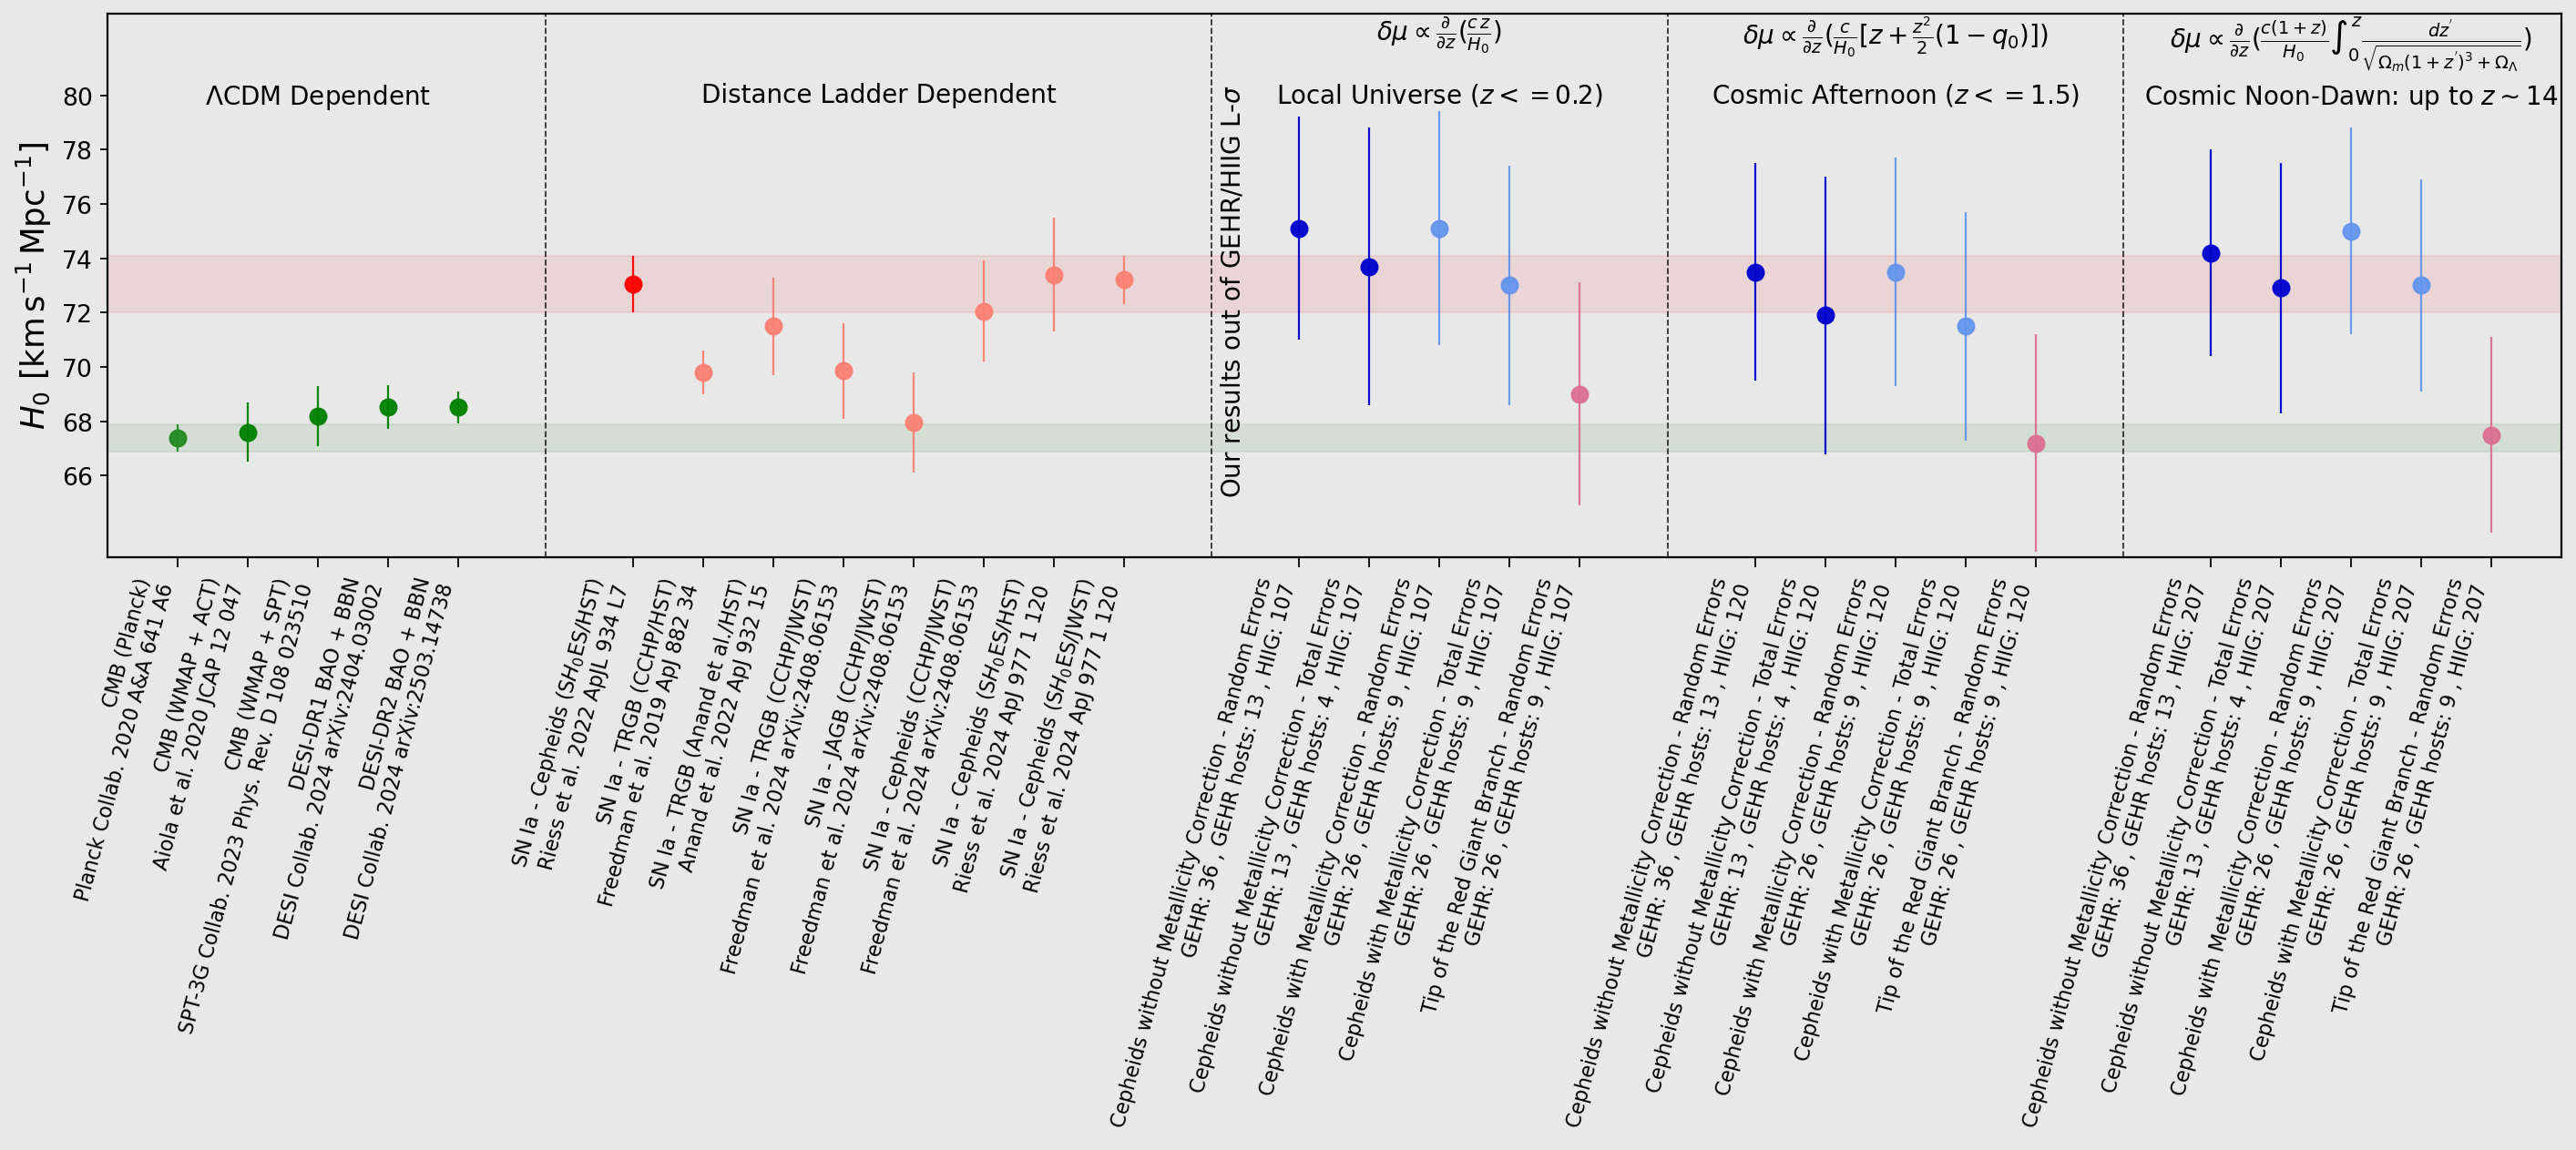

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Datos aproximados reconstruidos visualmente
# ============================================================

data = [
    # -------------------------------
    # Cosmological Model Dependent
    # -------------------------------
    {"group": "model", "label": "CMB (Planck)" + "\n" + "Planck Collab. 2020 A&A 641 A6",  "H0": 67.4, "err": 0.5, "color": "forestgreen"},
    {"group": "model", "label": "CMB (WMAP + ACT)" + "\n" + "Aiola et al. 2020 JCAP 12 047","H0": 67.6, "err": 1.1, "color": "green"},
    {"group": "model", "label": "CMB (WMAP + SPT)" + "\n" + "SPT-3G Collab. 2023 Phys. Rev. D 108 023510","H0": 68.2, "err": 1.1, "color": "green"},
    {"group": "model", "label": "DESI-DR1 BAO + BBN" + "\n" + "DESI Collab. 2024 arXiv:2404.03002","H0": 68.53, "err": 0.80, "color": "green"},
    {"group": "model", "label": "DESI-DR2 BAO + BBN" + "\n" + "DESI Collab. 2024 arXiv:2503.14738","H0": 68.51, "err": 0.58, "color": "green"},

    # -------------------------------
    # Direct (D vs z)
    # -------------------------------
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/HST)" + "\n" + "Riess et al. 2022 ApJL 934 L7","H0": 73.04, "err": 1.04, "color": "red"},
    {"group": "direct", "label": r"SN Ia - TRGB (CCHP/HST)" + "\n" + "Freedman et al. 2019 ApJ 882 34","H0": 69.80, "err": 0.80, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - TRGB (Anand et al./HST)" + "\n" + "Anand et al. 2022 ApJ 932 15","H0": 71.50, "err": 1.80, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - TRGB (CCHP/JWST)" + "\n" + "Freedman et al. 2024 arXiv:2408.06153","H0": 69.85, "err": 1.75, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - JAGB (CCHP/JWST)" + "\n" + "Freedman et al. 2024 arXiv:2408.06153","H0": 67.96, "err": 1.85, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - Cepheids (CCHP/JWST)" + "\n" + "Freedman et al. 2024 arXiv:2408.06153","H0": 72.05, "err": 1.86, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/HST)" + "\n" + "Riess et al. 2024 ApJ 977 1 120","H0": 73.40, "err": 2.10, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/JWST)" + "\n" + "Riess et al. 2024 ApJ 977 1 120","H0": 73.20, "err": 0.90, "color": "salmon"},

    # -------------------------------
    # L-sigma Local Universe 
    # -------------------------------
    {"group": "LU", "label": r"Cepheids without Metallicity Correction - Random Errors" + "\n" + "GEHR: 36 , GEHR hosts: 13 , HIIG: 107","H0": 75.1, "err": 4.1, "color": "mediumblue"},
    {"group": "LU", "label": r"Cepheids without Metallicity Correction - Total Errors" + "\n" + "GEHR: 13 , GEHR hosts: 4 , HIIG: 107","H0": 73.7, "err": 5.1, "color": "mediumblue"},
    {"group": "LU", "label": r"Cepheids with Metallicity Correction - Random Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 107","H0": 75.1, "err": 4.3, "color": "cornflowerblue"},
    {"group": "LU", "label": r"Cepheids with Metallicity Correction - Total Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 107","H0": 73.0, "err": 4.4, "color": "cornflowerblue"},
    {"group": "LU", "label": r"Tip of the Red Giant Branch - Random Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 107","H0": 69.0, "err": 4.1, "color": "palevioletred"},

    # -------------------------------
    # L-sigma Cosmic Afternoon 
    # -------------------------------

    {"group": "CA", "label": r"Cepheids without Metallicity Correction - Random Errors" + "\n" + "GEHR: 36 , GEHR hosts: 13 , HIIG: 120","H0": 73.50, "err": 4.0, "color": "mediumblue"},
    {"group": "CA", "label": r"Cepheids without Metallicity Correction - Total Errors" + "\n" + "GEHR: 13 , GEHR hosts: 4 , HIIG: 120","H0": 71.90, "err": 5.1, "color": "mediumblue"},
    {"group": "CA", "label": r"Cepheids with Metallicity Correction - Random Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 120","H0": 73.5, "err": 4.2, "color": "cornflowerblue"},
    {"group": "CA", "label": r"Cepheids with Metallicity Correction - Total Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 120","H0": 71.50, "err": 4.2, "color": "cornflowerblue"},
    {"group": "CA", "label": r"Tip of the Red Giant Branch - Random Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 120","H0": 67.2, "err": 4.0, "color": "palevioletred"},

    # -------------------------------
    # L-sigma Cosmic Noon to Cosmic Dawn 
    # -------------------------------
    {"group": "CND", "label": r"Cepheids without Metallicity Correction - Random Errors" + "\n" + "GEHR: 36 , GEHR hosts: 13 , HIIG: 207","H0": 74.2, "err": 3.8, "color": "mediumblue"},
    {"group": "CND", "label": r"Cepheids without Metallicity Correction - Total Errors" + "\n" + "GEHR: 13 , GEHR hosts: 4 , HIIG: 207","H0": 72.9, "err": 4.6, "color": "mediumblue"},
    {"group": "CND", "label": r"Cepheids with Metallicity Correction - Random Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 207","H0": 75.0, "err": 3.8, "color": "cornflowerblue"},
    {"group": "CND", "label": r"Cepheids with Metallicity Correction - Total Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 207","H0": 73.0, "err": 3.9, "color": "cornflowerblue"},
    {"group": "CND", "label": r"Tip of the Red Giant Branch - Random Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 207","H0": 67.5, "err": 3.6, "color": "palevioletred"},
]

# ============================================================
# Posiciones en x con espacios entre grupos
# ============================================================

gap = 1.5
x_positions = []
labels = []
group_positions = {"model": [], "direct": [], "LU": [], "CA": [], "CND": []}
separator_positions = []

current_x = 0
prev_group = data[0]["group"]

for i, d in enumerate(data):
    if i > 0 and d["group"] != prev_group:
        separator_positions.append(current_x - 0.5 + gap/2)
        current_x += gap
        prev_group = d["group"]

    x_positions.append(current_x)
    labels.append(d["label"])
    group_positions[d["group"]].append(current_x)
    current_x += 1

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=(18, 8), dpi=160)

bg = "#e8e8e8"
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)

# ============================================================
# Bandas horizontales de referencia (al rotar el gráfico)
# ============================================================

# Banda tipo Planck
ax.axhspan(66.9, 67.9, color="#8FBC8F", alpha=0.22, zorder=0)

# Banda tipo SH0ES
ax.axhspan(72.0, 74.08, color="#F08080", alpha=0.18, zorder=0)

# ============================================================
# Separadores verticales entre grupos
# ============================================================

for sep in separator_positions:
    ax.axvline(sep, color="black", ls="--", lw=0.8, alpha=0.8, zorder=1)

# ============================================================
# Puntos con barras de error verticales
# ============================================================

for x, d in zip(x_positions, data):
    ax.errorbar(
        x, d["H0"],
        yerr=d["err"],
        fmt='o',
        ms=8,
        color=d["color"],
        ecolor=d["color"],
        elinewidth=1.0,
        capsize=0,
        alpha=0.95,
        zorder=3
    )

# ============================================================
# Ejes
# ============================================================

ax.set_xlim(min(x_positions) - 1, max(x_positions) + 1)
ax.set_ylim(63, 83)

ax.set_xticks(x_positions)
ax.set_xticklabels(labels, rotation=75, ha="right", fontsize=10)

ax.set_yticks(np.arange(66, 81, 2))
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', length=5)

ax.set_ylabel(r"$H_0\ [\mathrm{km\, s^{-1}\, Mpc^{-1}}]$", fontsize=16)

# ============================================================
# Títulos de grupos
# ============================================================

ax.text(
    np.mean(group_positions["model"]), 80.5,
    r"$\Lambda$CDM Dependent",
    ha="center", va="top", fontsize=12.5
)

ax.text(
    np.mean(group_positions["direct"]), 80.5,
    r"Distance Ladder Dependent",
    ha="center", va="top", fontsize=12.5
)


ax.text(
    separator_positions[1]+0.3, 80.4,
    r"Our results out of GEHR/HIIG L-$\sigma$",
    ha="center", va="top", fontsize=12.5,rotation=90
)


ax.text(
    np.mean(group_positions["LU"]), 80.5,
    r"Local Universe ($z<=$0.2)",
    ha="center", va="top", fontsize=12.5
)

ax.text(
    np.mean(group_positions["CA"]), 80.5,
    r"Cosmic Afternoon ($z<=$1.5)",
    ha="center", va="top", fontsize=12.5
)

ax.text(
    np.mean(group_positions["CND"]), 80.5,
    r"Cosmic Noon-Dawn: up to $z \sim$14",
    ha="center", va="top", fontsize=12.5
)

# ============================================================
# Ecuaciones de error
# ============================================================


ax.text(
    np.mean(group_positions["LU"]), 83,
    r"$\delta \mu \propto \frac{\partial}{\partial z} ( \frac{c \, z}{H_0} )$",
    ha="center", va="top", fontsize=12.5
)


ax.text(
    np.mean(group_positions["CA"]), 83,
    r"$\delta \mu \propto \frac{\partial}{\partial z}$($\frac{c}{H_0}[z + \frac{z^2}{2}(1-q_0)]$)",
    ha="center", va="top", fontsize=12.5
)



ax.text(
    np.mean(group_positions["CND"]), 83,
    r"$\delta \mu \propto \frac{\partial}{\partial z}$($\frac{c (1+z)}{H_0} \int_0^z  \frac{dz^{'}}{\sqrt{\Omega_m (1+z^{'})^3 + \Omega_\Lambda}}  $)",
    ha="center", va="top", fontsize=12.5
)


# ============================================================
# Bordes
# ============================================================

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()

# Guardar si quieres
plt.savefig("H0_compilation_horizontal Low_mid_high CosmoError.png", dpi=300, bbox_inches="tight")
# plt.savefig("H0_compilation_horizontal.pdf", bbox_inches="tight")

plt.show()

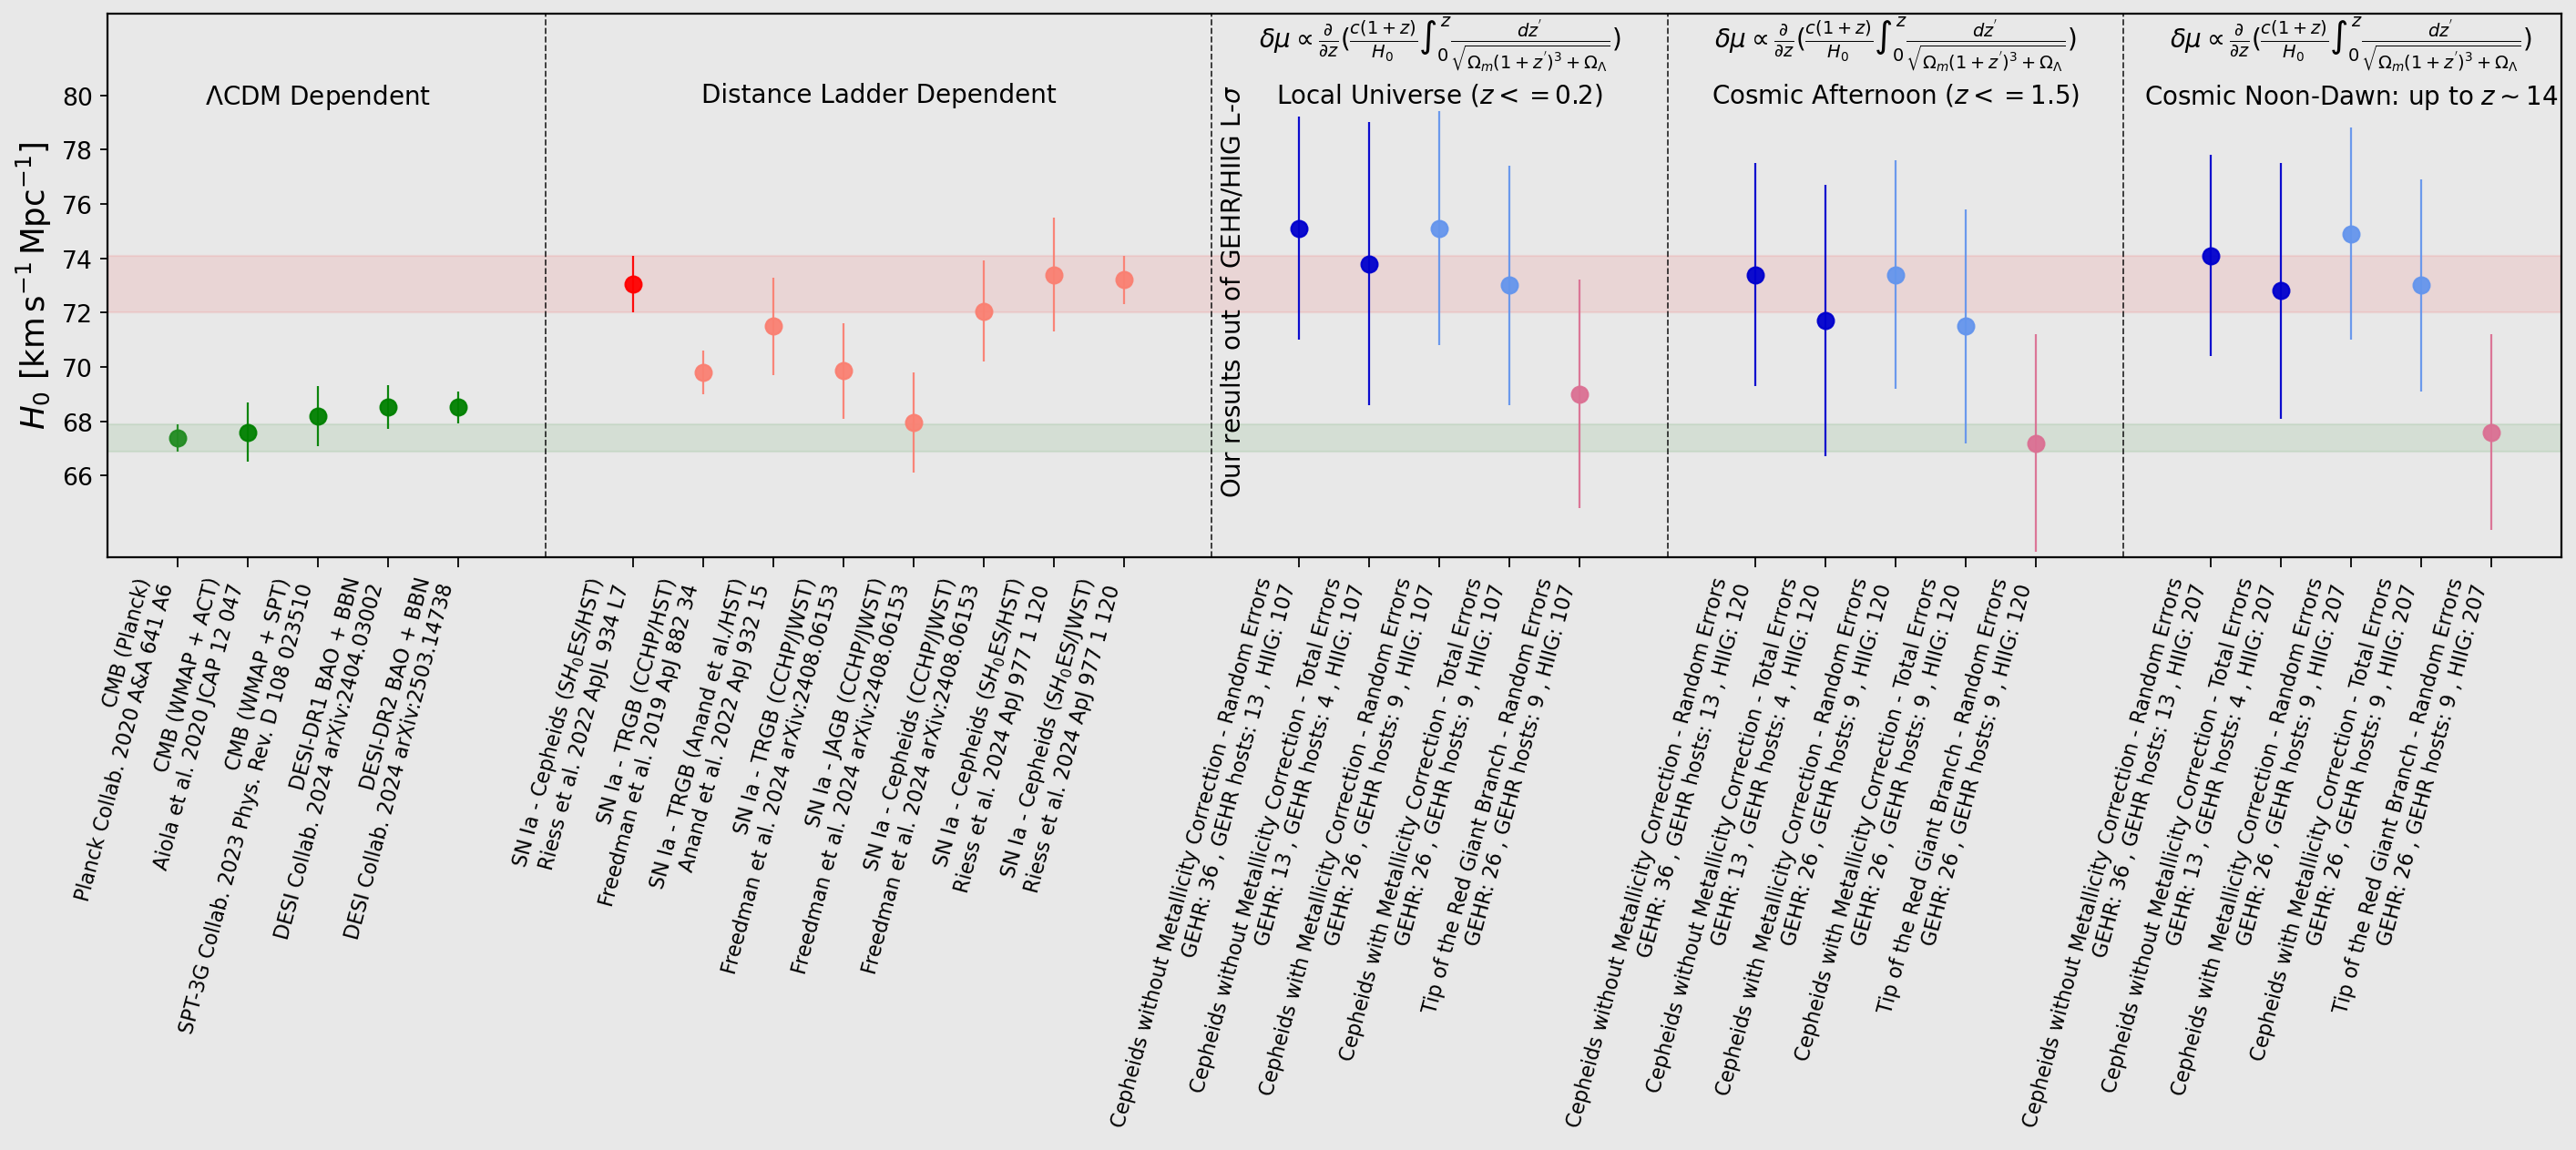

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Datos aproximados reconstruidos visualmente
# ============================================================

data = [
    # -------------------------------
    # Cosmological Model Dependent
    # -------------------------------
    {"group": "model", "label": "CMB (Planck)" + "\n" + "Planck Collab. 2020 A&A 641 A6",  "H0": 67.4, "err": 0.5, "color": "forestgreen"},
    {"group": "model", "label": "CMB (WMAP + ACT)" + "\n" + "Aiola et al. 2020 JCAP 12 047","H0": 67.6, "err": 1.1, "color": "green"},
    {"group": "model", "label": "CMB (WMAP + SPT)" + "\n" + "SPT-3G Collab. 2023 Phys. Rev. D 108 023510","H0": 68.2, "err": 1.1, "color": "green"},
    {"group": "model", "label": "DESI-DR1 BAO + BBN" + "\n" + "DESI Collab. 2024 arXiv:2404.03002","H0": 68.53, "err": 0.80, "color": "green"},
    {"group": "model", "label": "DESI-DR2 BAO + BBN" + "\n" + "DESI Collab. 2024 arXiv:2503.14738","H0": 68.51, "err": 0.58, "color": "green"},

    # -------------------------------
    # Direct (D vs z)
    # -------------------------------
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/HST)" + "\n" + "Riess et al. 2022 ApJL 934 L7","H0": 73.04, "err": 1.04, "color": "red"},
    {"group": "direct", "label": r"SN Ia - TRGB (CCHP/HST)" + "\n" + "Freedman et al. 2019 ApJ 882 34","H0": 69.80, "err": 0.80, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - TRGB (Anand et al./HST)" + "\n" + "Anand et al. 2022 ApJ 932 15","H0": 71.50, "err": 1.80, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - TRGB (CCHP/JWST)" + "\n" + "Freedman et al. 2024 arXiv:2408.06153","H0": 69.85, "err": 1.75, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - JAGB (CCHP/JWST)" + "\n" + "Freedman et al. 2024 arXiv:2408.06153","H0": 67.96, "err": 1.85, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - Cepheids (CCHP/JWST)" + "\n" + "Freedman et al. 2024 arXiv:2408.06153","H0": 72.05, "err": 1.86, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/HST)" + "\n" + "Riess et al. 2024 ApJ 977 1 120","H0": 73.40, "err": 2.10, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/JWST)" + "\n" + "Riess et al. 2024 ApJ 977 1 120","H0": 73.20, "err": 0.90, "color": "salmon"},

    # -------------------------------
    # L-sigma Local Universe 
    # -------------------------------
    {"group": "LU", "label": r"Cepheids without Metallicity Correction - Random Errors" + "\n" + "GEHR: 36 , GEHR hosts: 13 , HIIG: 107","H0": 75.1, "err": 4.1, "color": "mediumblue"},
    {"group": "LU", "label": r"Cepheids without Metallicity Correction - Total Errors" + "\n" + "GEHR: 13 , GEHR hosts: 4 , HIIG: 107","H0": 73.8, "err": 5.2, "color": "mediumblue"},
    {"group": "LU", "label": r"Cepheids with Metallicity Correction - Random Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 107","H0": 75.1, "err": 4.3, "color": "cornflowerblue"},
    {"group": "LU", "label": r"Cepheids with Metallicity Correction - Total Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 107","H0": 73.0, "err": 4.4, "color": "cornflowerblue"},
    {"group": "LU", "label": r"Tip of the Red Giant Branch - Random Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 107","H0": 69.0, "err": 4.2, "color": "palevioletred"},

    # -------------------------------
    # L-sigma Cosmic Afternoon 
    # -------------------------------

    {"group": "CA", "label": r"Cepheids without Metallicity Correction - Random Errors" + "\n" + "GEHR: 36 , GEHR hosts: 13 , HIIG: 120","H0": 73.40, "err": 4.1, "color": "mediumblue"},
    {"group": "CA", "label": r"Cepheids without Metallicity Correction - Total Errors" + "\n" + "GEHR: 13 , GEHR hosts: 4 , HIIG: 120","H0": 71.70, "err": 5.0, "color": "mediumblue"},
    {"group": "CA", "label": r"Cepheids with Metallicity Correction - Random Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 120","H0": 73.4, "err": 4.2, "color": "cornflowerblue"},
    {"group": "CA", "label": r"Cepheids with Metallicity Correction - Total Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 120","H0": 71.5, "err": 4.3, "color": "cornflowerblue"},
    {"group": "CA", "label": r"Tip of the Red Giant Branch - Random Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 120","H0": 67.2, "err": 4.0, "color": "palevioletred"},

    # -------------------------------
    # L-sigma Cosmic Noon to Cosmic Dawn 
    # -------------------------------
    {"group": "CND", "label": r"Cepheids without Metallicity Correction - Random Errors" + "\n" + "GEHR: 36 , GEHR hosts: 13 , HIIG: 207","H0": 74.1, "err": 3.7, "color": "mediumblue"},
    {"group": "CND", "label": r"Cepheids without Metallicity Correction - Total Errors" + "\n" + "GEHR: 13 , GEHR hosts: 4 , HIIG: 207","H0": 72.8, "err": 4.7, "color": "mediumblue"},
    {"group": "CND", "label": r"Cepheids with Metallicity Correction - Random Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 207","H0": 74.9, "err": 3.9, "color": "cornflowerblue"},
    {"group": "CND", "label": r"Cepheids with Metallicity Correction - Total Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 207","H0": 73.0, "err": 3.9, "color": "cornflowerblue"},
    {"group": "CND", "label": r"Tip of the Red Giant Branch - Random Errors" + "\n" + "GEHR: 26 , GEHR hosts: 9 , HIIG: 207","H0": 67.6, "err": 3.6, "color": "palevioletred"},
]

# ============================================================
# Posiciones en x con espacios entre grupos
# ============================================================

gap = 1.5
x_positions = []
labels = []
group_positions = {"model": [], "direct": [], "LU": [], "CA": [], "CND": []}
separator_positions = []

current_x = 0
prev_group = data[0]["group"]

for i, d in enumerate(data):
    if i > 0 and d["group"] != prev_group:
        separator_positions.append(current_x - 0.5 + gap/2)
        current_x += gap
        prev_group = d["group"]

    x_positions.append(current_x)
    labels.append(d["label"])
    group_positions[d["group"]].append(current_x)
    current_x += 1

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=(18, 8), dpi=160)

bg = "#e8e8e8"
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)

# ============================================================
# Bandas horizontales de referencia (al rotar el gráfico)
# ============================================================

# Banda tipo Planck
ax.axhspan(66.9, 67.9, color="#8FBC8F", alpha=0.22, zorder=0)

# Banda tipo SH0ES
ax.axhspan(72.0, 74.08, color="#F08080", alpha=0.18, zorder=0)

# ============================================================
# Separadores verticales entre grupos
# ============================================================

for sep in separator_positions:
    ax.axvline(sep, color="black", ls="--", lw=0.8, alpha=0.8, zorder=1)

# ============================================================
# Puntos con barras de error verticales
# ============================================================

for x, d in zip(x_positions, data):
    ax.errorbar(
        x, d["H0"],
        yerr=d["err"],
        fmt='o',
        ms=8,
        color=d["color"],
        ecolor=d["color"],
        elinewidth=1.0,
        capsize=0,
        alpha=0.95,
        zorder=3
    )

# ============================================================
# Ejes
# ============================================================

ax.set_xlim(min(x_positions) - 1, max(x_positions) + 1)
ax.set_ylim(63, 83)

ax.set_xticks(x_positions)
ax.set_xticklabels(labels, rotation=75, ha="right", fontsize=10)

ax.set_yticks(np.arange(66, 81, 2))
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', length=5)

ax.set_ylabel(r"$H_0\ [\mathrm{km\, s^{-1}\, Mpc^{-1}}]$", fontsize=16)

# ============================================================
# Títulos de grupos
# ============================================================

ax.text(
    np.mean(group_positions["model"]), 80.5,
    r"$\Lambda$CDM Dependent",
    ha="center", va="top", fontsize=12.5
)

ax.text(
    np.mean(group_positions["direct"]), 80.5,
    r"Distance Ladder Dependent",
    ha="center", va="top", fontsize=12.5
)


ax.text(
    separator_positions[1]+0.3, 80.4,
    r"Our results out of GEHR/HIIG L-$\sigma$",
    ha="center", va="top", fontsize=12.5,rotation=90
)


ax.text(
    np.mean(group_positions["LU"]), 80.5,
    r"Local Universe ($z<=$0.2)",
    ha="center", va="top", fontsize=12.5
)

ax.text(
    np.mean(group_positions["CA"]), 80.5,
    r"Cosmic Afternoon ($z<=$1.5)",
    ha="center", va="top", fontsize=12.5
)

ax.text(
    np.mean(group_positions["CND"]), 80.5,
    r"Cosmic Noon-Dawn: up to $z \sim$14",
    ha="center", va="top", fontsize=12.5
)

# ============================================================
# Ecuaciones de error
# ============================================================


ax.text(
    np.mean(group_positions["LU"]), 83,
    r"$\delta \mu \propto \frac{\partial}{\partial z}$($\frac{c (1+z)}{H_0} \int_0^z  \frac{dz^{'}}{\sqrt{\Omega_m (1+z^{'})^3 + \Omega_\Lambda}}  $)",
    ha="center", va="top", fontsize=12.5
)


ax.text(
    np.mean(group_positions["CA"]), 83,
    r"$\delta \mu \propto \frac{\partial}{\partial z}$($\frac{c (1+z)}{H_0} \int_0^z  \frac{dz^{'}}{\sqrt{\Omega_m (1+z^{'})^3 + \Omega_\Lambda}}  $)",
    ha="center", va="top", fontsize=12.5
)



ax.text(
    np.mean(group_positions["CND"]), 83,
    r"$\delta \mu \propto \frac{\partial}{\partial z}$($\frac{c (1+z)}{H_0} \int_0^z  \frac{dz^{'}}{\sqrt{\Omega_m (1+z^{'})^3 + \Omega_\Lambda}}  $)",
    ha="center", va="top", fontsize=12.5
)


# ============================================================
# Bordes
# ============================================================

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()

# Guardar si quieres
plt.savefig("H0_compilation_horizontal high_only CosmoError.png", dpi=300, bbox_inches="tight")
# plt.savefig("H0_compilation_horizontal.pdf", bbox_inches="tight")

plt.show()

/tmp/ipykernel_1538776/3353217863.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


OK - figura guardada


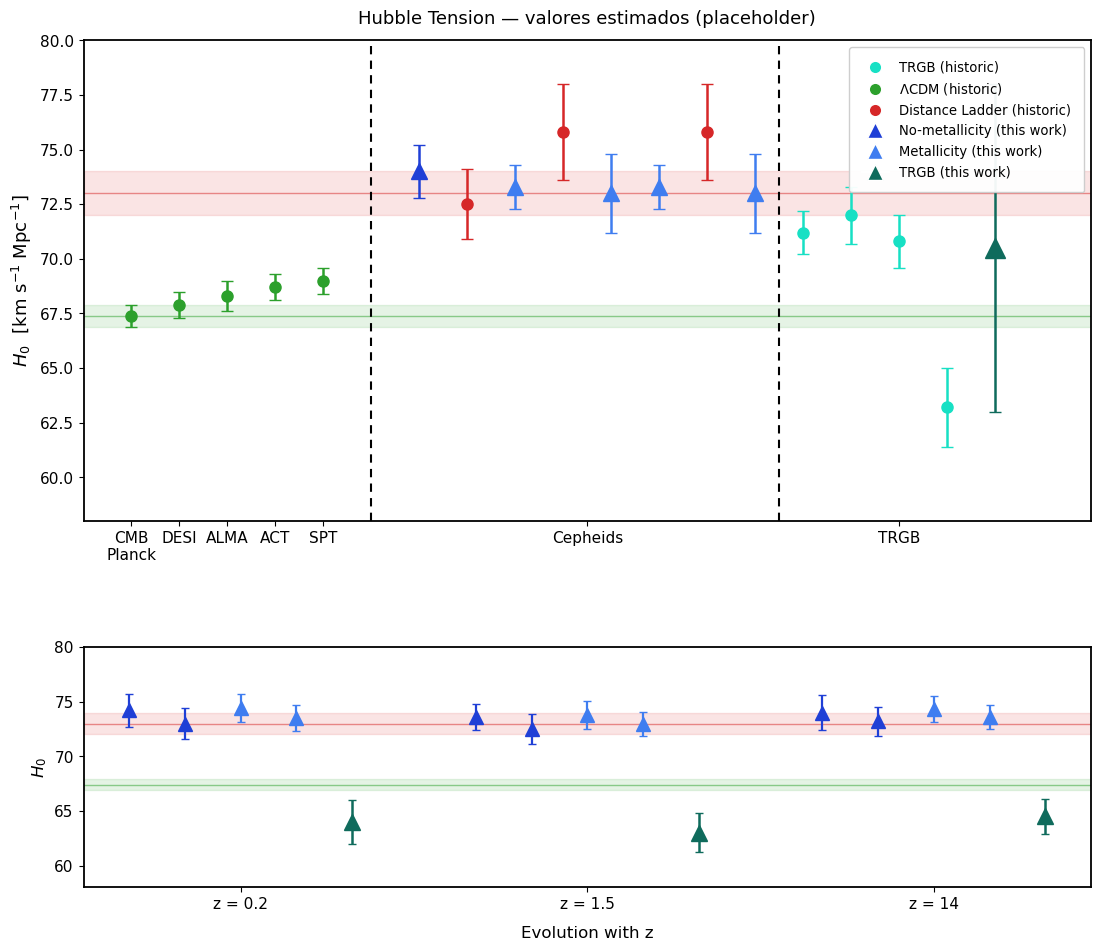

In [4]:
"""
Hubble Tension plot - replica del boceto de Holman.
Datos ESTIMADOS a partir de la imagen subida; reemplazar con valores reales
del análisis (L-sigma relation, GEHR/HIIG, etc.) cuando estén disponibles.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ---------------------------------------------------------------
# 1. DATOS ESTIMADOS (editar aquí con tus valores reales)
# ---------------------------------------------------------------

# --- Bandas de referencia (Planck/LambdaCDM vs SH0ES/Distance Ladder) ---
PLANCK_H0, PLANCK_ERR = 67.4, 0.5      # Planck 2018
SHOES_H0, SHOES_ERR = 73.0, 1.0        # SH0ES (Riess et al.)

# --- Bloque 1: Historic LambdaCDM / CMB (verde) ---
lcdm_labels = ["CMB\nPlanck", "DESI", "ALMA", "ACT", "SPT"]
lcdm_x = np.array([1, 2, 3, 4, 5])
lcdm_y = np.array([67.4, 67.9, 68.3, 68.7, 69.0])
lcdm_yerr = np.array([0.5, 0.6, 0.7, 0.6, 0.6])

# --- Bloque 2: Cefeidas (Distance Ladder=rojo, This work=azul) ---
ceph_x = np.array([7, 8, 9, 10, 11, 12, 13, 14])
ceph_y = np.array([74.0, 72.5, 73.3, 75.8, 73.0, 73.3, 75.8, 73.0])
ceph_yerr = np.array([1.2, 1.6, 1.0, 2.2, 1.8, 1.0, 2.2, 1.8])
# tipo: 'dl' = Distance Ladder (rojo, circulo), 'nometal'/'metal' = This work (azul, triangulo)
ceph_kind = ["nometal", "dl", "metal", "dl", "metal", "metal", "dl", "metal"]

# --- Bloque 3: TRGB (Historic=cian, This work=verde oscuro) ---
trgb_x = np.array([15, 16, 17, 18, 19])
trgb_y = np.array([71.2, 72.0, 70.8, 63.2, 70.5])
trgb_yerr = np.array([1.0, 1.3, 1.2, 1.8, 7.5])
trgb_kind = ["hist", "hist", "hist", "hist", "thiswork"]

# --- Panel inferior: Evolución con z para "This work" ---
# 3 grupos en z = 0.2, 1.5, 14 ; cada grupo: no-metal, metal, TRGB
z_groups = [0.2, 1.5, 14]
z_offsets = [-0.6, -0.2, 0.2, 0.6]  # no-metal x2, metal x2 dentro de cada grupo (estimado del boceto)

eta_data = {
    0.2: {
        "nometal": [(74.2, 1.5), (73.0, 1.4)],
        "metal":   [(74.4, 1.3), (73.5, 1.2)],
        "trgb":    [(64.0, 2.0)],
    },
    1.5: {
        "nometal": [(73.6, 1.2), (72.5, 1.4)],
        "metal":   [(73.8, 1.3), (73.0, 1.1)],
        "trgb":    [(63.0, 1.8)],
    },
    14: {
        "nometal": [(74.0, 1.6), (73.2, 1.3)],
        "metal":   [(74.3, 1.2), (73.6, 1.1)],
        "trgb":    [(64.5, 1.6)],
    },
}

# ---------------------------------------------------------------
# 2. ESTILO
# ---------------------------------------------------------------

COLOR_LCDM = "#2ca02c"       # verde - Historic LCDM
COLOR_DL = "#d62728"         # rojo - Historic Distance Ladder
COLOR_TRGB_HIST = "#17e0c4"  # cian - Historic TRGB
COLOR_NOMETAL = "#1f3fd6"    # azul oscuro - This work no-metalicity
COLOR_METAL = "#3f7df0"      # azul claro - This work metalicity
COLOR_TRGB_NEW = "#0f6b5c"   # verde oscuro - This work TRGB

plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.3,
    "figure.facecolor": "white",
})

fig = plt.figure(figsize=(13, 11))
gs = GridSpec(2, 1, height_ratios=[2.0, 1.0], hspace=0.35)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1])

# ---------------------------------------------------------------
# 3. PANEL SUPERIOR
# ---------------------------------------------------------------

# Bandas horizontales sombreadas
for ax in (ax_top, ax_bot):
    ax.axhspan(PLANCK_H0 - PLANCK_ERR, PLANCK_H0 + PLANCK_ERR,
               color=COLOR_LCDM, alpha=0.12, zorder=0)
    ax.axhspan(SHOES_H0 - SHOES_ERR, SHOES_H0 + SHOES_ERR,
               color=COLOR_DL, alpha=0.12, zorder=0)
    ax.axhline(PLANCK_H0, color=COLOR_LCDM, lw=1.0, alpha=0.5, zorder=0)
    ax.axhline(SHOES_H0, color=COLOR_DL, lw=1.0, alpha=0.5, zorder=0)

# --- Bloque historic LCDM (circulos verdes) ---
ax_top.errorbar(lcdm_x, lcdm_y, yerr=lcdm_yerr, fmt="o", color=COLOR_LCDM,
                 ecolor=COLOR_LCDM, elinewidth=1.8, capsize=4, markersize=8,
                 zorder=3)

# --- Bloque Cefeidas (rojo=dl circulo, azul=this work triangulo) ---
for x, y, yerr, kind in zip(ceph_x, ceph_y, ceph_yerr, ceph_kind):
    if kind == "dl":
        ax_top.errorbar(x, y, yerr=yerr, fmt="o", color=COLOR_DL,
                         ecolor=COLOR_DL, elinewidth=1.8, capsize=4,
                         markersize=8, zorder=3)
    elif kind == "nometal":
        ax_top.errorbar(x, y, yerr=yerr, fmt="^", color=COLOR_NOMETAL,
                         ecolor=COLOR_NOMETAL, elinewidth=1.8, capsize=4,
                         markersize=12, zorder=3)
    elif kind == "metal":
        ax_top.errorbar(x, y, yerr=yerr, fmt="^", color=COLOR_METAL,
                         ecolor=COLOR_METAL, elinewidth=1.8, capsize=4,
                         markersize=12, zorder=3)

# --- Bloque TRGB (cian=historic circulo, verde oscuro=this work triangulo) ---
for x, y, yerr, kind in zip(trgb_x, trgb_y, trgb_yerr, trgb_kind):
    if kind == "hist":
        ax_top.errorbar(x, y, yerr=yerr, fmt="o", color=COLOR_TRGB_HIST,
                         ecolor=COLOR_TRGB_HIST, elinewidth=1.8, capsize=4,
                         markersize=8, zorder=3)
    else:
        ax_top.errorbar(x, y, yerr=yerr, fmt="^", color=COLOR_TRGB_NEW,
                         ecolor=COLOR_TRGB_NEW, elinewidth=1.8, capsize=4,
                         markersize=14, zorder=3)

# Separadores verticales punteados entre bloques
ax_top.axvline(6, color="black", ls=(0, (4, 3)), lw=1.5, zorder=2)
ax_top.axvline(14.5, color="black", ls=(0, (4, 3)), lw=1.5, zorder=2)

# Eje x: etiquetas de grupo
ceph_center = float(np.mean(ceph_x))   # centro real del bloque Cefeidas
trgb_center = float(np.mean(trgb_x))   # centro real del bloque TRGB
ax_top.set_xticks(list(lcdm_x) + [ceph_center, trgb_center])
ax_top.set_xticklabels(lcdm_labels + ["Cepheids", "TRGB"])

ax_top.set_ylabel(r"$H_0$  [km s$^{-1}$ Mpc$^{-1}$]", fontsize=13)
ax_top.set_ylim(58, 80)
ax_top.set_xlim(0, 21)
ax_top.set_title("Hubble Tension — valores estimados (placeholder)", fontsize=13, pad=12)

# ---------------------------------------------------------------
# 4. LEYENDA (replicando el cuadro del boceto)
# ---------------------------------------------------------------

legend_elems = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_TRGB_HIST,
           markersize=9, label="TRGB (historic)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_LCDM,
           markersize=9, label=r"$\Lambda$CDM (historic)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_DL,
           markersize=9, label="Distance Ladder (historic)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor=COLOR_NOMETAL,
           markersize=11, label="No-metallicity (this work)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor=COLOR_METAL,
           markersize=11, label="Metallicity (this work)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor=COLOR_TRGB_NEW,
           markersize=11, label="TRGB (this work)"),
]
ax_top.legend(handles=legend_elems, loc="upper right", fontsize=9.5,
              framealpha=0.95, ncol=1, title="", borderpad=1.0)

# ---------------------------------------------------------------
# 5. PANEL INFERIOR: evolución con z
# ---------------------------------------------------------------

xpos = []
xlabels = []
base = 0
group_centers = []

for gi, z in enumerate(z_groups):
    d = eta_data[z]
    n_nometal = len(d["nometal"])
    n_metal = len(d["metal"])
    n_trgb = len(d["trgb"])
    n_total = n_nometal + n_metal + n_trgb
    xs = base + np.arange(n_total) * 0.9
    idx = 0

    for (y, yerr) in d["nometal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="^", color=COLOR_NOMETAL,
                         ecolor=COLOR_NOMETAL, elinewidth=1.6, capsize=3,
                         markersize=10, zorder=3)
        idx += 1
    for (y, yerr) in d["metal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="^", color=COLOR_METAL,
                         ecolor=COLOR_METAL, elinewidth=1.6, capsize=3,
                         markersize=10, zorder=3)
        idx += 1
    for (y, yerr) in d["trgb"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="^", color=COLOR_TRGB_NEW,
                         ecolor=COLOR_TRGB_NEW, elinewidth=1.8, capsize=3,
                         markersize=12, zorder=3)
        idx += 1

    group_centers.append(np.mean(xs))
    base = xs[-1] + 2.0  # espacio entre grupos

ax_bot.set_xticks(group_centers)
ax_bot.set_xticklabels([f"z = {z}" for z in z_groups])
ax_bot.set_ylabel(r"$H_0$", fontsize=12)
ax_bot.set_ylim(58, 80)
ax_bot.set_xlabel("Evolution with z", fontsize=12, labelpad=10)

plt.tight_layout()
plt.savefig("hubble_tension.png", dpi=180, bbox_inches="tight")
print("OK - figura guardada")

In [2]:
LSdata_df = pd.read_csv('Compilation2026.csv',comment='#',index_col=False, dtype={'GEHR_id': str})
LS_tab = Table.from_pandas(LSdata_df)
LS_tab

index,z_or_mu,e_z_or_e_mu,log_sigma,e_log_sigma,log_f_Hbeta,e_log_f_Hbeta,origin_id,GEHR_id
int64,float64,float64,float64,float64,float64,float64,float64,str11
0,24.22,0.13,1.1803352,0.0136779,-10.2477404749,0.0576746197553,0.0,1.IC0010
1,24.22,0.13,1.1144041,0.0117835,-10.4759303122,0.0616196977511,0.0,1.IC0010
2,29.15,0.1,1.4143135,0.0233959,-11.0543846363,0.0571859387529,0.0,5.M101
3,29.15,0.1,1.3692392,0.0211037,-11.9205675872,0.0529003364017,0.0,5.M101
4,29.15,0.1,1.2958639,0.0178817,-11.8613707404,0.0609810126943,0.0,5.M101
5,29.15,0.1,1.3043677,0.0182209,-12.0887781044,0.0414250431862,0.0,5.M101
6,29.15,0.1,1.3026601,0.0181555,-11.8302225581,0.0592690973202,0.0,5.M101
7,24.58,0.1,1.1051128,0.0114869,-11.3192839883,0.0962665899784,0.0,3.M33
8,24.58,0.1,1.0106166,0.0093596,-11.5662672307,0.0815293027404,0.0,3.M33


### Funciones de error para plotear L-sigma

In [ ]:
'''      
if len(set_) != 0 and codeX != 0.0:
            cosmo = FlatwCDM(H0=h*100.0, Om0=0.3, w0=-1.0)
            z = set_['z_or_mu']
            logf_z = set_['log_f_Hbeta']
            err_logf_z = set_['e_log_f_Hbeta']
            err_z = set_['e_z_or_e_mu']
            # distancia de luminosidad
            dL = cosmo.luminosity_distance(z)            # Mpc
            dL_cm = dL.to(u.cm).value
            logL = logf_z + 2*np.log10(dL_cm) + np.log10(4*np.pi)
            # Propagación de errores en z (numérica)
            logL_z = logL.copy()
            logL_z_plus = np.zeros_like(logL_z)
            for i in range(len(z)):
                zp = z[i] + err_z[i]
                if zp <= 0:
                    zp = z[i]  # por seguridad
                dL_p = cosmo.luminosity_distance(zp).to(u.cm).value
                logL_z_plus[i] = logf_z[i] + 2*np.log10(dL_p) + np.log10(4*np.pi)
            sigma_logL_z = np.abs(logL_z_plus - logL_z)
            e_logL = np.sqrt(err_logf_z**2 + sigma_logL_z**2)
            logSigma = set_['log_sigma']
            e_logSigma = set_['e_log_sigma']
            ax.errorbar(
                logSigma,
                logL,
                color = colors[codeX],
                xerr=e_logSigma,
                yerr=e_logL,
                fmt=markers[codeX],
                linestyle="none",
                label=samples[codeX],
                alpha=0.8,
                capsize=5,
                markersize=10
            )
            return ax
'''

In [24]:
def GEHR_plotter_code0(DF=None,ax=None):
    if DF is not None and ax is not None:
        set_ = DF[(DF['origin_id'] == 0.0)]
        if len(set_) != 0:
            pc_to_cm = 3.08567758e18
            zeta = pc_to_cm 
            logL = np.log10(4*np.pi*(zeta)**2) + ((2*set_['z_or_mu'] +10)/5) + set_['log_f_Hbeta']
            e_logL = np.sqrt(((2/5)*set_['e_z_or_e_mu'])**2 + (set_['e_log_f_Hbeta'])**2)
            logSigma = set_['log_sigma']
            e_logSigma = set_['e_log_sigma']
            ax.errorbar(
                logSigma,
                logL,
                color = "brown",
                xerr=e_logSigma,
                yerr=e_logL,
                fmt="s",
                linestyle="none",
                label="GEHR (Local)",
                alpha=0.8,
                capsize=5,
                markersize=10
            )
            return ax

def HIIGlocal_plotter_code1(DF=None,ax=None,mode=None,h=None,e_h=None):
    if DF is not None and ax is not None and mode is not None and h is not None and e_h is not None:
        set_ = DF[(DF['origin_id'] == 1.0)]
        if len(set_) != 0:
            Mpc_to_cm = 3.08567758e24
            #km_to_cm = 100000
            eta = Mpc_to_cm #* km_to_cm
            c = 299792.458 #km/s

            if mode == 'Local':
                logL = np.log10(4*np.pi*(eta)**2*c**2) + (2*np.log10(set_['z_or_mu'])) - (2*np.log10(h*100)) + set_['log_f_Hbeta']
                e_logL = np.sqrt((set_['e_z_or_e_mu'] * (2/(set_['z_or_mu']*np.log(10))))**2    + (e_h * (-2/(h*np.log(10))))**2   + (set_['e_log_f_Hbeta'])**2)
                logSigma = set_['log_sigma']
                e_logSigma = set_['e_log_sigma']
                ax.errorbar(
                    logSigma,
                    logL,
                    color = "blue",
                    xerr=e_logSigma,
                    yerr=e_logL,
                    fmt="o",
                    linestyle="none",
                    label="Local",
                    alpha=0.8,
                    capsize=5,
                    markersize=10
                )
                return ax

            if mode == 'Intermediate':
                pass

            if mode == 'Full':
                pass



In [45]:
def L_sigma_plotter(DF=None,ax=None,codeX=None,h=None,e_h=None):
    if DF is not None and ax is not None and h is not None and e_h is not None and codeX is not None:
        cosmo = FlatwCDM(H0=h*100.0, Om0=0.3, w0=-1.0)
        set_ = DF[(DF['origin_id'] == codeX)]
        markers = {
            0: "s",   # square
            1: "o",   # circle
            2: "D",   # diamond
            3: "^",   # triangle up
            4: "v",   # triangle down
            5: "x",   # x
            6: "*",   # star
            7: "P",   # filled plus
            8: "h",   # hexagon
        }

        colors = {
            0: "brown",
            1: "blue",
            2: "green",
            3: "red",
            4: "orange",
            5: "gray",
            6: "purple",
            7: "teal",
            8: "black",
        }
        samples = {
            0: "GEHR",
            1: "Local HIIG",
            2: "Liter.Mid-z",
            3: "VLT/X-shooter",
            4: "Keck/MOSFIRE",
            5: "VLT/KMOS",
            6: "JWST/NIRSpec",
            7: "VUDS/VANDELS",
            8: "ALMA+JWST/MIRI"
        }

        if len(set_) != 0 and codeX == 0.0:
            pc_to_cm = 3.08567758e18
            zeta = pc_to_cm 
            logL = np.log10(4*np.pi*(zeta)**2) + ((2*set_['z_or_mu'] +10)/5) + set_['log_f_Hbeta']
            e_logL = np.sqrt(((2/5)*set_['e_z_or_e_mu'])**2 + (set_['e_log_f_Hbeta'])**2)
            logSigma = set_['log_sigma']
            e_logSigma = set_['e_log_sigma']
            ax.errorbar(
                logSigma,
                logL,
                color = colors[codeX],
                xerr=e_logSigma,
                yerr=e_logL,
                fmt=markers[codeX],
                linestyle="none",
                label=samples[codeX],
                alpha=0.8,
                capsize=5,
                markersize=10
            )
            return ax            

        if len(set_) != 0 and codeX != 0.0:
            #if mode == 'Local':
            Mpc_to_cm = 3.08567758e24
            #km_to_cm = 100000
            eta = Mpc_to_cm #* km_to_cm
            c = 299792.458 #km/s
            Ez = cosmo.efunc(set_['z_or_mu'])  # E(z) = H(z)/H0
            # I(z) = integral_0^z dz'/E(z') = (H0/c) * D_C(z)
            Iz = (cosmo.comoving_distance(set_['z_or_mu']) * cosmo.H0 / const.c).to_value(u.dimensionless_unscaled)
            logL = np.log10(4*np.pi*(eta)**2*c**2) - (2*np.log10(h*100)) + set_['log_f_Hbeta'] + (2*np.log10(1 + set_['z_or_mu']))  + (2*np.log10(Iz)) 
            e_logL = np.sqrt(((2.0/np.log(10.0)) * (1.0/(1.0+set_['z_or_mu']) + 1.0/(Ez*Iz)) * set_['e_z_or_e_mu'])**2 + (e_h * (-2/(h*np.log(10))))**2   + (set_['e_log_f_Hbeta'])**2)
            logSigma = set_['log_sigma']
            e_logSigma = set_['e_log_sigma']
            ax.errorbar(
                logSigma,
                logL,
                color = colors[codeX],
                xerr=e_logSigma,
                yerr=e_logL,
                fmt=markers[codeX],
                linestyle="none",
                label=samples[codeX],
                alpha=0.8,
                capsize=5,
                markersize=10
            )
            #ax.scatter(logSigma, logL, s=set_['z_or_mu'], alpha=0.2, c=set_['z_or_mu'], cmap='viridis', edgecolors='black')
            return ax



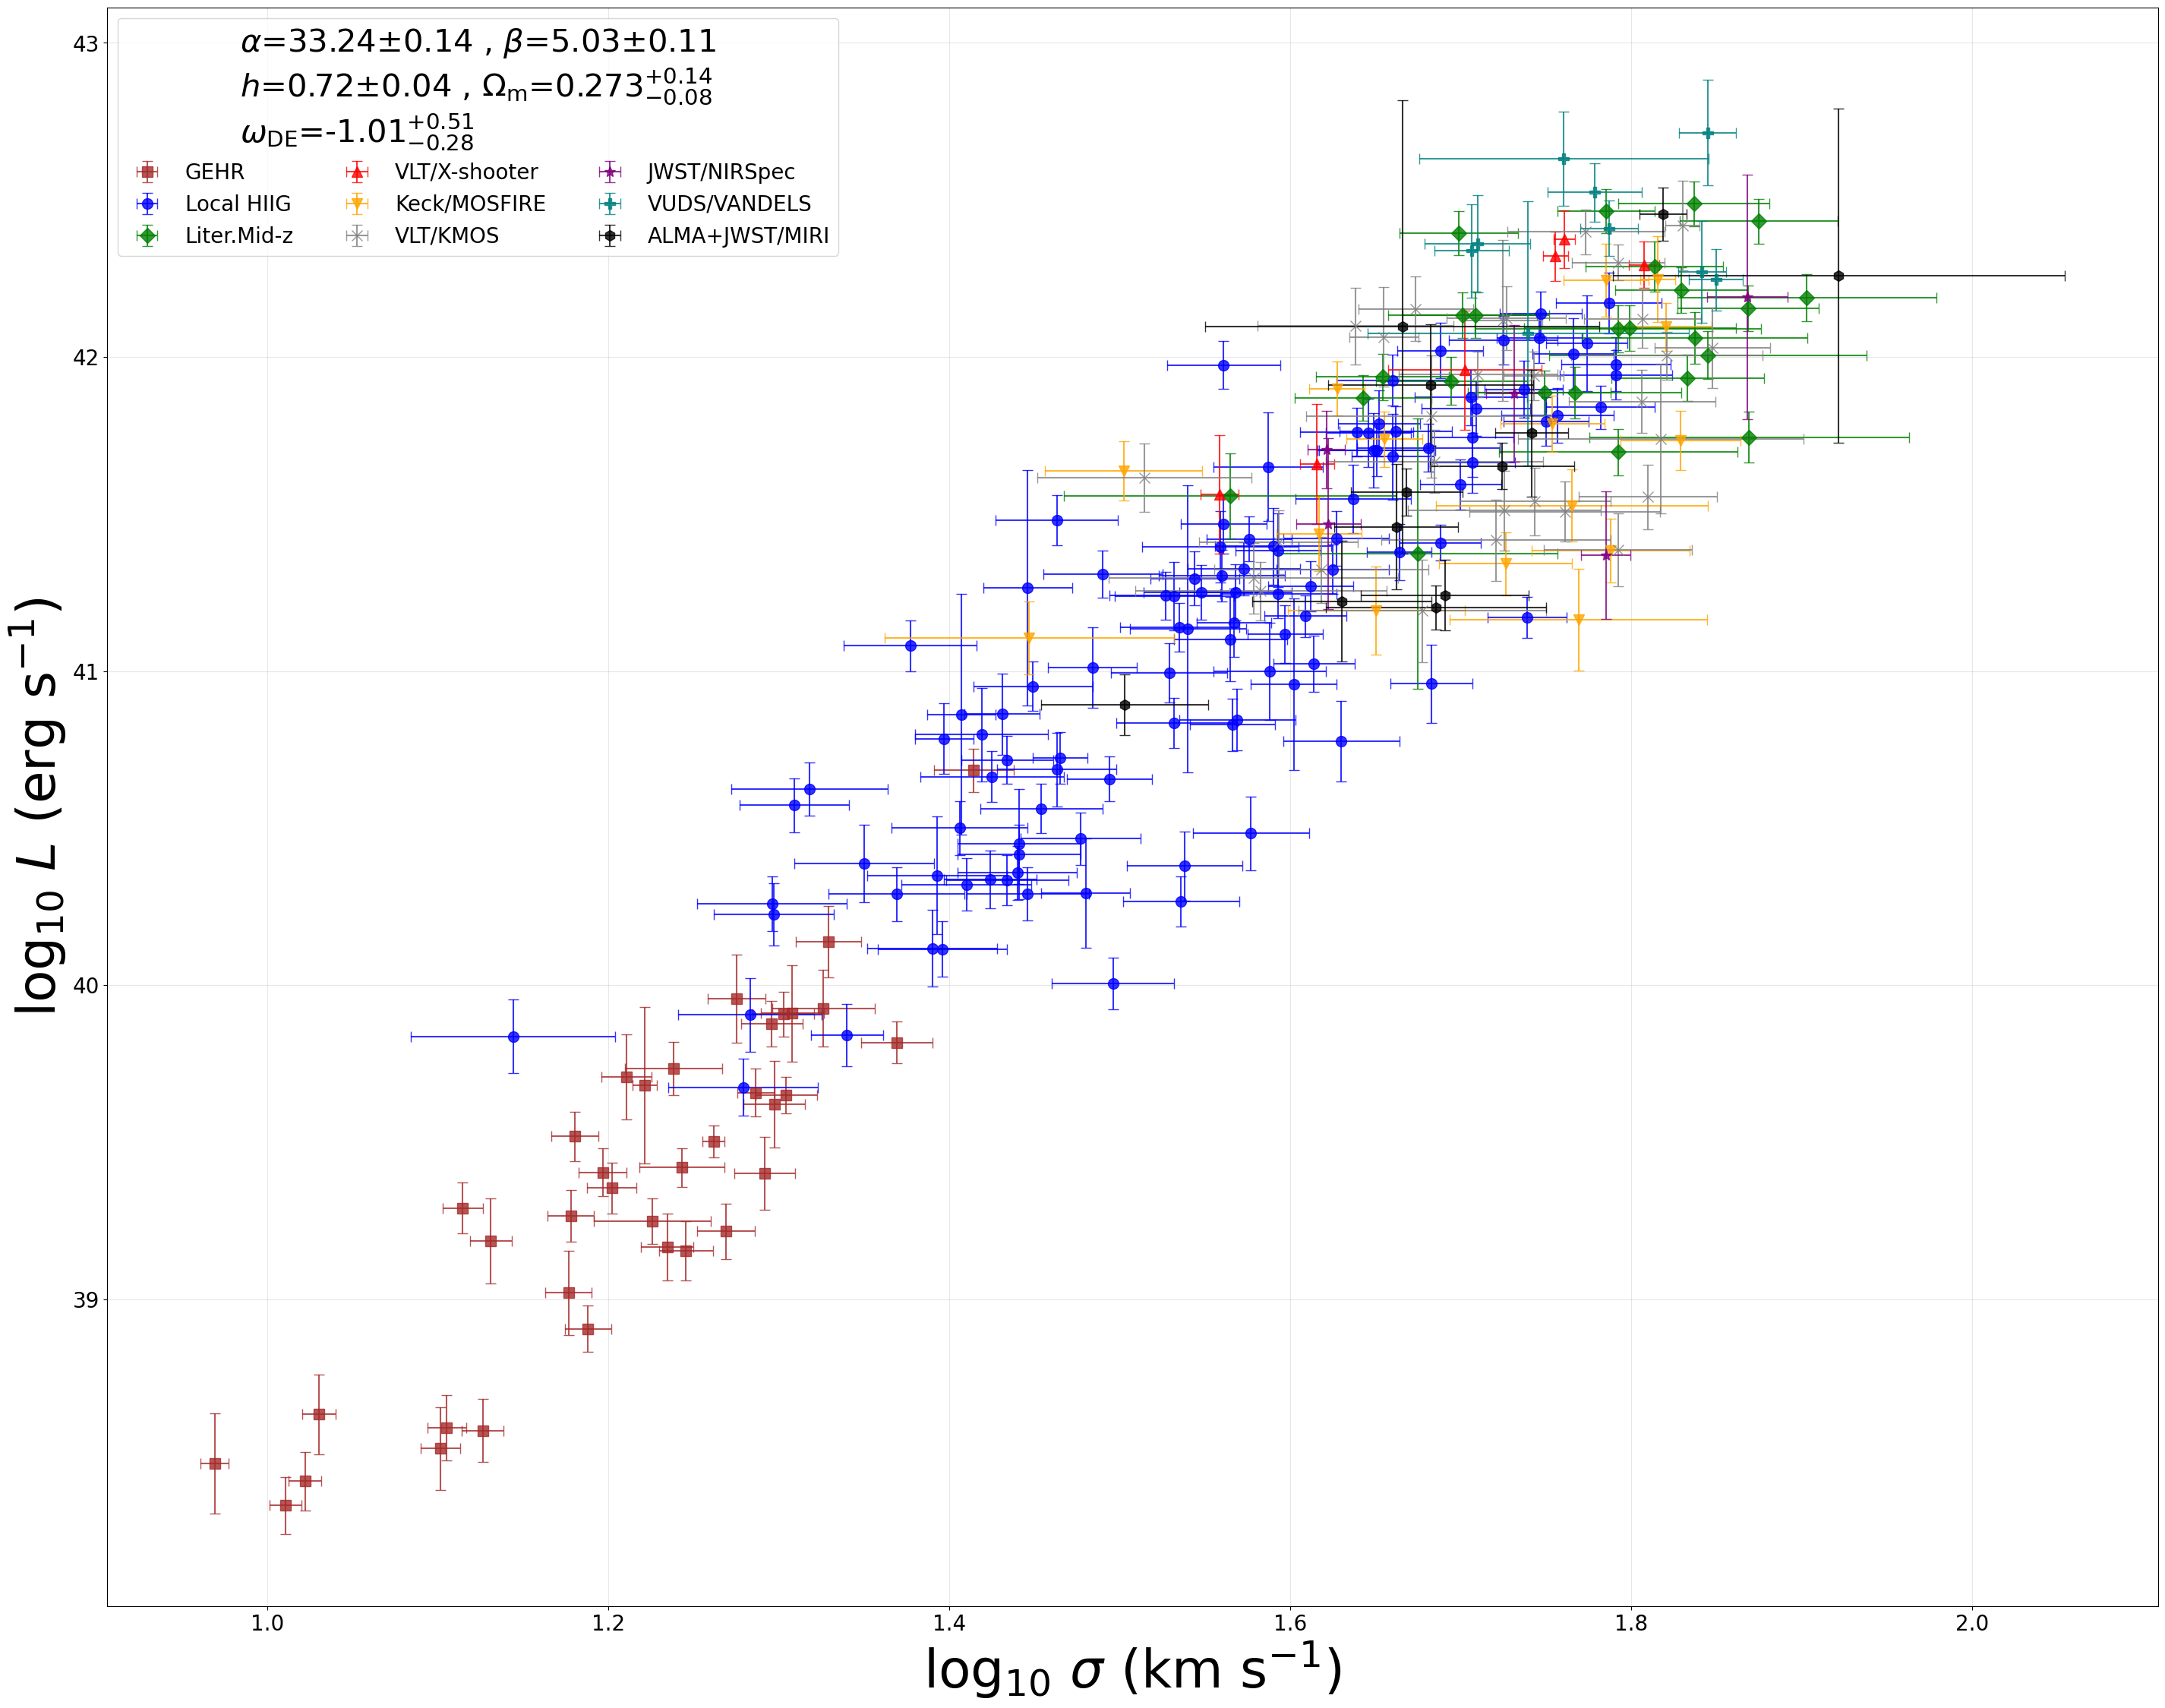

In [49]:
fig, ax = plt.subplots(figsize=(28.617329728, 22.592767987), dpi = 100)


L_sigma_plotter(DF=LS_tab,ax=ax,codeX=0.0,h=0.70,e_h=0.041)
L_sigma_plotter(DF=LS_tab,ax=ax,codeX=1.0,h=0.70,e_h=0.041)
L_sigma_plotter(DF=LS_tab,ax=ax,codeX=2.0,h=0.70,e_h=0.041)
L_sigma_plotter(DF=LS_tab,ax=ax,codeX=3.0,h=0.70,e_h=0.041)
L_sigma_plotter(DF=LS_tab,ax=ax,codeX=4.0,h=0.70,e_h=0.041)
L_sigma_plotter(DF=LS_tab,ax=ax,codeX=5.0,h=0.70,e_h=0.041)
L_sigma_plotter(DF=LS_tab,ax=ax,codeX=6.0,h=0.70,e_h=0.041)
L_sigma_plotter(DF=LS_tab,ax=ax,codeX=7.0,h=0.70,e_h=0.041)
L_sigma_plotter(DF=LS_tab,ax=ax,codeX=8.0,h=0.70,e_h=0.041)

#GEHR_plotter_code0(DF=LS_tab,ax=ax)
#HIIGlocal_plotter_code1(DF=LS_tab,ax=ax,mode='Local',h=0.680,e_h=0.041)


ax.set_xlabel(r"$\log_{10}\, \sigma\ \mathrm{(km\ s^{-1})}$", fontsize = 50)
ax.set_ylabel(r"$\log_{10}\, L\ \mathrm{(erg\ s^{-1})}$", fontsize = 50)
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', labelsize=20) # Changes x-axis tick label font size
ax.tick_params(axis='y', labelsize=20) 


ax.legend(ncol= 3,
          title=r"$\alpha$=33.24$\pm$0.14 , "  + 
          r"$\beta$=5.03$\pm$0.11" + "\n" + 
          r"$h$=0.72$\pm$0.04 , "  + 
          r"$\Omega_\text{m}$=0.273$^{+0.14}_{-0.08}$" + "\n" + 
          r"$\omega_\text{DE}$=-1.01$^{+0.51}_{-0.28}$",
          title_fontsize=30,
          fontsize = 20)


plt.tight_layout()
plt.show()


In [76]:
prefix = '/home/holman/HIIGalaxies/Bayesian_samplers/Multinest/Local_CepcZeR_sigma_w/low_cepczer_sigma_w_zle0p1_'
samples  = pymultinest.analyse.Analyzer(n_params = 3, outputfiles_basename=prefix)

  analysing data from /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/Local_CepcZeR_sigma_w/low_cepczer_sigma_w_zle0p1_.txt


In [75]:
analyzer = pymultinest.analyse.Analyzer(
    n_params=3,
    outputfiles_basename=prefix
)

stats = analyzer.get_stats()

  analysing data from /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/Local_CepcZeR_sigma_w/low_cepczer_sigma_w_zle0p1_.txt


In [70]:
stats['modes'][0]['mean']

[33.27710504533049, 5.040484633804169, 0.6753337696669021]

In [71]:
home_Ho = os.path.expanduser("~//home/holman/HIIGalaxies/Bayesian_samplers/Multinest/")    # Path para los resultados
results_path = os.path.join(home_Ho, 'asdad','ddddd')
results_path

'/home/holman//home/holman/HIIGalaxies/Bayesian_samplers/Multinest/asdad/ddddd'

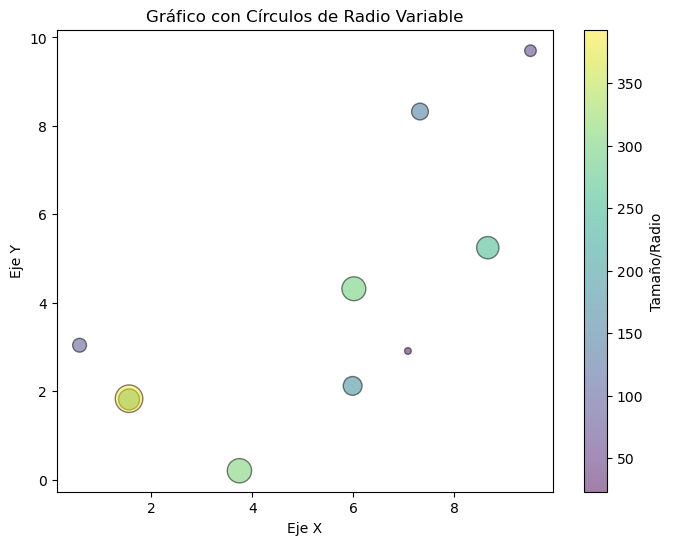

In [31]:
# 1. Definir coordenadas y radios (valores de radio variable)
np.random.seed(42)
x = np.random.rand(10) * 10
y = np.random.rand(10) * 10
radios = np.random.rand(10) * 500  # Radios variables elevados a escala

# 2. Crear el gráfico
fig, ax = plt.subplots(figsize=(8, 6))

# Dibujar los círculos
# Nota: el parámetro 's' toma el área del círculo (aproximadamente r^2 * pi)
scatter = ax.scatter(x, y, s=radios, alpha=0.5, c=radios, cmap='viridis', edgecolors='black')

# 3. Ajustes opcionales de formato
ax.set_title("Gráfico con Círculos de Radio Variable")
ax.set_xlabel("Eje X")
ax.set_ylabel("Eje Y")
plt.colorbar(scatter, label="Tamaño/Radio")

# Mostrar gráfico
plt.show()

In [ ]:
samples = {
    0: "GEHR",
    1: "HIIG Locales",
    2: "Erb+06",
    3: "X-Shooter",
    4: "MOSFIRE",
    5: "KMOS",
}

markers = {0: "s", 1: "o", 2: "D", 3: "^", 4: "v", 5: "x"}
colors = {0: "brown", 1: "blue", 2: "green", 3: "red", 4: "orange", 5: "gray"}

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(28.617329728, 22.592767987), dpi = 100)

samples = {
    0: "GEHR",
    1: "HIIG Locales",
    2: "Erb+06",
    3: "X-Shooter",
    4: "MOSFIRE",
    5: "KMOS",
}

markers = {0: "s", 1: "o", 2: "D", 3: "^", 4: "v", 5: "x"}
colors = {0: "brown", 1: "blue", 2: "green", 3: "red", 4: "orange", 5: "gray"}

for s, label in samples.items():
    m = flag == s
    if not np.any(m):
        continue
    ax.errorbar(
        log_sigma[m],
        logL[m],
        color = colors[s],
        xerr=err_logsig[m],
        yerr=err_logL[m],
        fmt=markers[s],
        linestyle="none",
        label=label,
        alpha=0.8,
        capsize=5,
        markersize=10
    )

ax.set_xlabel(r"$\log_{10}\, \sigma\ \mathrm{(km\ s^{-1})}$", fontsize = 50)
ax.set_ylabel(r"$\log_{10}\, L\ \mathrm{(erg\ s^{-1})}$", fontsize = 50)
ax.legend()
ax.grid(True, alpha=0.3)

#mask_fit = (flag == 0) | (flag == 1) | (flag == 2) | (flag == 3) | (flag == 4) | (flag == 5)
mask_fit = (flag == 0) | (flag == 1)


x = log_sigma[mask_fit]
y = logL[mask_fit]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

slope, intercept = 5.03 , 33.24 


# recta ajustada
x_line = np.linspace(x.min()-0.05, x.max()+0.05, 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, label=r"Ajuste", color = 'k', linestyle = '--')


ax.tick_params(axis='x', labelsize=20) # Changes x-axis tick label font size
ax.tick_params(axis='y', labelsize=20) 


ax.legend(ncol= 3,
          title=r"$\alpha$=33.24$\pm$0.14 , "  + 
          r"$\beta$=5.03$\pm$0.11" + "\n" + 
          r"$h$=0.72$\pm$0.04 , "  + 
          r"$\Omega_\text{m}$=0.273$^{+0.14}_{-0.08}$" + "\n" + 
          r"$\omega_\text{DE}$=-1.01$^{+0.51}_{-0.28}$",
          title_fontsize=50,
          fontsize = 40)


plt.tight_layout()
plt.show()


### GEHR only

In [109]:
GEHR = LS_tab[(LS_tab['origin_id'] == 0.0)]

In [5]:
def GEHR_logL(mu,logF,e_mu,e_logF):
    d = (10**((mu+5)/5)) * pc_to_cm # cm
    F = 10 ** logF # erg s^-1 cm^-2
    L = 4 * np.pi * d**2 * F # erg s^-1
    logL = np.log10(L)
    e_PT = 4/25 * (e_mu**2) 
    e_ST = e_logF**2
    e_logL = np.sqrt(e_PT+e_ST)
    return logL,e_logL

In [6]:
LHb_GEHR = GEHR_logL(GEHR['z_or_mu'],GEHR['log_f_Hbeta'],GEHR['e_z_or_e_mu'],GEHR['e_log_f_Hbeta'])
sigma_GEHR = [GEHR['log_sigma'],GEHR['e_log_sigma']]

<ErrorbarContainer object of 3 artists>

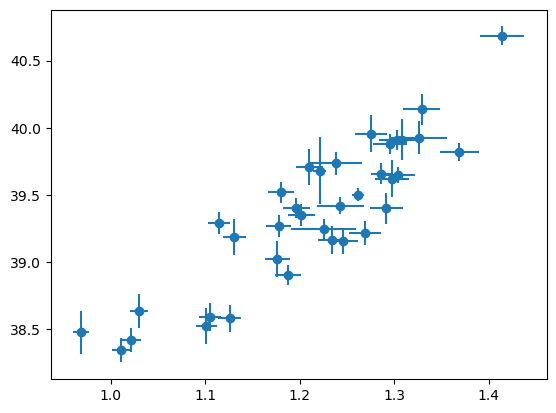

In [7]:
plt.errorbar(sigma_GEHR[0],LHb_GEHR[0],
             xerr=sigma_GEHR[1],yerr=LHb_GEHR[1],
             fmt='o')

In [8]:
def lnlike_GEHR(theta, logS, logF, muObs, e_logS, e_logF, e_muObs):
    alpha, beta = theta
    A = 2.5*(alpha + beta*logS) - (2.5*logF) + 100.19477738511641
    B = muObs
    C = 2.5 * np.sqrt((e_logS*beta)**2+(e_logF)**2)
    D = e_muObs
    U = (A-B)**2
    N = (C)**2 + (D)**2
    chi_sq = np.sum(U/N)
    ln_like = -1 * (1/2) * chi_sq
    return ln_like 

In [9]:
def prior_transform(u):
    alpha = 20.0 + 20.0 * u[0]     # 20->40
    beta  =  0.0 + 10.0 * u[1]     # 0->10
    return np.array([alpha, beta])

In [10]:
def nll(theta):
    return -lnlike_GEHR(theta, GEHR['log_sigma'], GEHR['log_f_Hbeta'], GEHR['z_or_mu'],
                         GEHR['e_log_sigma'], GEHR['e_log_f_Hbeta'], GEHR['e_z_or_e_mu'])

res = op.minimize(nll, 
                  x0=[32.0, 5.0], method="Nelder-Mead")
print("ML guess:", res.x)

ML guess: [-46.9173138    5.02811421]


In [11]:
outdir = os.path.join(os.path.expanduser('~/HIIGalaxies/Bayesian_samplers/Multinest'), "GEHR_only")
os.makedirs(outdir, exist_ok=True)
prefix = os.path.join(outdir, "hii_")

def loglike_for_GEHR(theta):
    return lnlike_GEHR(theta, GEHR['log_sigma'], GEHR['log_f_Hbeta'], GEHR['z_or_mu'],
                         GEHR['e_log_sigma'], GEHR['e_log_f_Hbeta'], GEHR['e_z_or_e_mu'])

In [12]:
n_dims = 2
result = pymultinest.solve(
    LogLikelihood=loglike_for_GEHR,
    Prior=prior_transform,
    n_dims=n_dims,
    outputfiles_basename=prefix,
    evidence_tolerance=0.5,
    n_live_points=1000,
    multimodal=True,
    verbose=True
)

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points = 1000
 dimensionality =    2
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        1.000000
Replacements:                               1050
Total Samples:                              1050
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z): ************** +/-  0.999524
Acceptance Rate:                        0.997280
Replacements:                               1100
Total Samples:                              1103
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z): ************** +/-  0.999547
Acceptance Rate:                        0.993092
Replacements:                               1150


In [13]:
print("\nEvidence lnZ = %.3f ± %.3f" % (result["logZ"], result["logZerr"]))
samples = result["samples"]   # shape = (Nsamples, 3)
parameters = [r"\alpha", r"\beta", r"h"]
print("Posterior means/stdev:")
for name, col in zip(parameters, samples.T):
    print(f"{name:>6s}: {col.mean():.3f} ± {col.std():.3f}")


with open(prefix + "params.json", "w") as f:
    json.dump(parameters, f, indent=2)

fig = corner.corner(
    samples,
    labels=[r"$\alpha$", r"$\beta$", r"$h$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84]
)
fig.savefig(prefix + "corner.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Corner guardado en:", prefix + "corner.png")


Evidence lnZ = -3178625.294 ± 0.165
Posterior means/stdev:
\alpha: 20.006 ± 0.000
 \beta: 9.997 ± 0.000
Corner guardado en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/GEHR_only/hii_corner.png


Removed no burn in
GetDist triangle en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/GEHR_only/hii_triangle_getdist.png

Listo. Archivos en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/GEHR_only


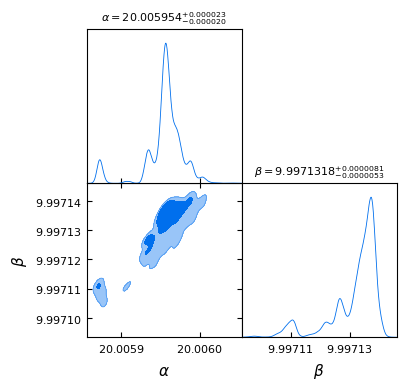

In [14]:
gds = MCSamples(
    samples=samples,
    names=["alpha", "beta"],
    labels=[r"\alpha", r"\beta"]  
)
g = plots.getSubplotPlotter()
g.settings.num_plot_contours = 2
g.triangle_plot([gds], filled=True, title_limit=1)
g.export(prefix + "triangle_getdist.png")
print("GetDist triangle en:", prefix + "triangle_getdist.png")

print("\nListo. Archivos en:", outdir)

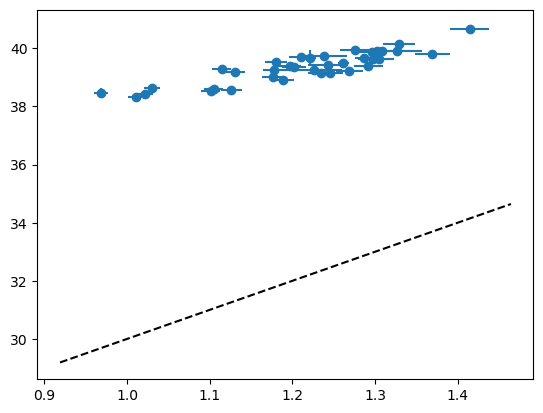

In [15]:
plt.errorbar(sigma_GEHR[0],LHb_GEHR[0],
             xerr=sigma_GEHR[1],yerr=LHb_GEHR[1],
             fmt='o')

x_line = np.linspace(sigma_GEHR[0].min()-0.05, sigma_GEHR[0].max()+0.05, 100)
y_line = 9.997 * x_line +  20.006

plt.plot(x_line, y_line, label=r"Ajuste", color = 'k', linestyle = '--')

### Local_universe (Standard)

In [90]:
local_universe = LS_tab[(LS_tab['origin_id'] == 0.0) | ((LS_tab['origin_id'] != 0.0) & (LS_tab['z_or_mu'] <= 0.10))]

In [91]:
def lnlike_LU(theta,DF):
    alpha, beta, h0 = theta
    cosmo = FlatwCDM(H0=h0*100.0, Om0=0.3, w0=-1.0)

    G = local_universe['origin_id'] == 0.0
    H = local_universe['origin_id'] != 0.0


    Mum = DF['z_or_mu'] * 0.0
    MumErr = DF['e_z_or_e_mu'] * 0.0

    Mum[G] = DF[G]['z_or_mu']
    MumErr[G] = DF[G]['e_z_or_e_mu']
    Mum[H] = 5.0*np.log10(cosmo.luminosity_distance(DF[H]['z_or_mu']).value) + 25.0
    MumErr[H] = (5.0/np.log(10.0))*(DF[H]['e_z_or_e_mu']/DF[H]['z_or_mu'])

    Mu = 2.5*(beta*DF['log_sigma'] + alpha) - 2.5*DF['log_f_Hbeta'] - 100.19477738511641
    MuErr = 2.5*np.sqrt((DF['e_log_f_Hbeta'])**2 + beta**2*(DF['e_log_sigma'])**2)

    R = (Mu - Mum)
    W = 1.0/(MuErr**2 + MumErr**2)

    xsq = np.sum(R**2 * W)
    llq = -0.5*xsq
    return llq


In [92]:
def prior_transform(u):
    alpha = 20.0 + 20.0 * u[0]     # 20->40
    beta  =  0.0 + 10.0 * u[1]     # 0->10
    h0    =  0.5 +  0.5 * u[2]     # 0.5->1.0
    return np.array([alpha, beta, h0])

In [93]:
def nll(theta):
    return -lnlike_LU(theta,local_universe)

res = op.minimize(nll, x0=[32.0, 5.0, 0.75], method="Nelder-Mead")
print("ML guess:", res.x)

ML guess: [33.2316836   5.03376931  0.72016568]


In [81]:
outdir = os.path.join(os.path.expanduser('~/HIIGalaxies/Bayesian_samplers/Multinest'), "LocalUniverse")
os.makedirs(outdir, exist_ok=True)
prefix = os.path.join(outdir, "hii_")

def loglike_for_LU(theta):
    return lnlike_LU(theta,local_universe)

In [82]:
n_dims = 3
result = pymultinest.solve(
    LogLikelihood=loglike_for_LU,
    Prior=prior_transform,
    n_dims=n_dims,
    outputfiles_basename=prefix,
    evidence_tolerance=0.5,
    n_live_points=300,
    multimodal=True,
    verbose=True
)

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  300
 dimensionality =    3
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.974930
Replacements:                                350
Total Samples:                               359
Nested Sampling ln(Z):            -628319.071376
Importance Nested Sampling ln(Z):    -358.867880 +/-  0.991302
Acceptance Rate:                        0.921659
Replacements:                                400
Total Samples:                               434
Nested Sampling ln(Z):            -189231.652210
Importance Nested Sampling ln(Z):    -359.057603 +/-  0.991545
Acceptance Rate:                        0.882353
Replacements:                                450


In [83]:
print("\nEvidence lnZ = %.3f ± %.3f" % (result["logZ"], result["logZerr"]))


samples = result["samples"]   # shape = (Nsamples, 3)
parameters = [r"\alpha", r"\beta", r"h"]
print("Posterior means/stdev:")
for name, col in zip(parameters, samples.T):
    print(f"{name:>6s}: {col.mean():.3f} ± {col.std():.3f}")


with open(prefix + "params.json", "w") as f:
    json.dump(parameters, f, indent=2)

fig = corner.corner(
    samples,
    labels=[r"$\alpha$", r"$\beta$", r"$h$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84]
)
fig.savefig(prefix + "corner.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Corner guardado en:", prefix + "corner.png")


Evidence lnZ = -269.797 ± 0.185
Posterior means/stdev:
\alpha: 33.222 ± 0.157
 \beta: 5.042 ± 0.129
     h: 0.720 ± 0.044
Corner guardado en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/LocalUniverse/hii_corner.png


Removed no burn in
GetDist triangle en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/LocalUniverse/hii_triangle_getdist.png

Listo. Archivos en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/LocalUniverse


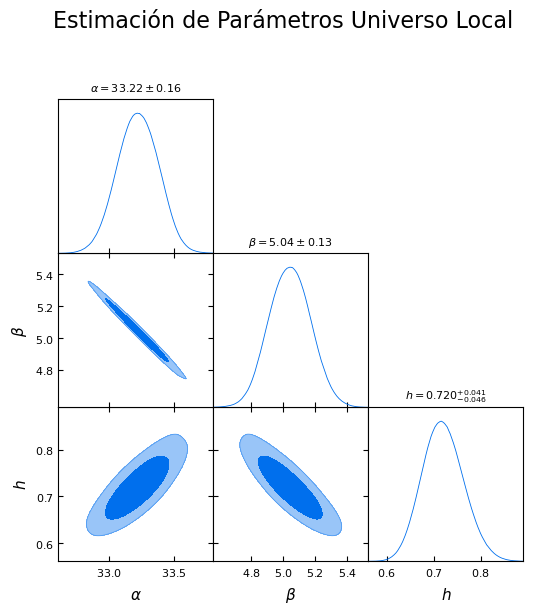

In [89]:

gds = MCSamples(
    samples=samples,
    names=["alpha", "beta", "h"],
    labels=[r"\alpha", r"\beta", r"h"]  
)
g = plots.getSubplotPlotter()
g.settings.num_plot_contours = 2
g.triangle_plot([gds], filled=True, title_limit=1)
g.fig.suptitle("Estimación de Parámetros Universo Local", fontsize=16, y=1.03)
g.export(prefix + "triangle_getdist.png")
print("GetDist triangle en:", prefix + "triangle_getdist.png")

print("\nListo. Archivos en:", outdir)

In [110]:
GEHR = LS_tab[(LS_tab['origin_id'] == 0.0)]
GEHR

index,z_or_mu,e_z_or_e_mu,log_sigma,e_log_sigma,log_f_Hbeta,e_log_f_Hbeta,origin_id,GEHR_id
int64,float64,float64,float64,float64,float64,float64,float64,str11
0,24.22,0.13,1.1803352,0.0136779,-10.2477404749,0.0576746197553,0.0,1.IC0010
1,24.22,0.13,1.1144041,0.0117835,-10.4759303122,0.0616196977511,0.0,1.IC0010
2,29.15,0.1,1.4143135,0.0233959,-11.0543846363,0.0571859387529,0.0,5.M101
3,29.15,0.1,1.3692392,0.0211037,-11.9205675872,0.0529003364017,0.0,5.M101
4,29.15,0.1,1.2958639,0.0178817,-11.8613707404,0.0609810126943,0.0,5.M101
5,29.15,0.1,1.3043677,0.0182209,-12.0887781044,0.0414250431862,0.0,5.M101
6,29.15,0.1,1.3026601,0.0181555,-11.8302225581,0.0592690973202,0.0,5.M101
7,24.58,0.1,1.1051128,0.0114869,-11.3192839883,0.0962665899784,0.0,3.M33
8,24.58,0.1,1.0106166,0.0093596,-11.5662672307,0.0815293027404,0.0,3.M33


In [ ]:
def group_reader(DF, group):
    # 1. Convertir a pandas si viene como Astropy Table
    DF_pd = DF.to_pandas()
    df_group = pd.read_csv(group)
    # 2. Obtener la lista de galaxias únicas del grupo para el filtro principal
    galaxies_in_group = df_group['Galaxia'].unique()
    # 3. Aplicar tu filtro original
    filtro = DF_pd[DF_pd['GEHR_id'].isin(galaxies_in_group) | (DF_pd['origin_id'] > 0.0)].copy()
    # 4. Hacer un merge por izquierda para traer 'mu_w' y 'sigma_w' basados en la coincidencia de ID
    filtro = filtro.merge(
        df_group[['Galaxia', 'mu_w', 'sigma_w']], 
        left_on='GEHR_id', 
        right_on='Galaxia', 
        how='left'
    )
    # 5. Identificar las filas donde efectivamente hubo coincidencia (no son NaN)
    coincide = filtro['mu_w'].notna()
    # 6. Reemplazar los valores exclusivamente para las coincidencias
    filtro.loc[coincide, 'z_or_mu'] = filtro.loc[coincide, 'mu_w']
    filtro.loc[coincide, 'e_z_or_e_mu'] = filtro.loc[coincide, 'sigma_w']
    # 7. Limpiar las columnas auxiliares del merge para mantener el DF limpio
    filtro = filtro.drop(columns=['Galaxia', 'mu_w', 'sigma_w'])
    # 8. Regresar a Astropy Table
    new_DF = Table.from_pandas(filtro)
    return new_DF

group_reader(GEHR, group='t_r.csv')

index,z_or_mu,e_z_or_e_mu,log_sigma,e_log_sigma,log_f_Hbeta,e_log_f_Hbeta,origin_id,GEHR_id
int64,float64,float64,float64,float64,float64,float64,float64,str10
0,24.22,0.13,1.1803352,0.0136779,-10.2477404749,0.0576746197553,0.0,1.IC0010
1,24.22,0.13,1.1144041,0.0117835,-10.4759303122,0.0616196977511,0.0,1.IC0010
2,29.15,0.1,1.4143135,0.0233959,-11.0543846363,0.0571859387529,0.0,5.M101
3,29.15,0.1,1.3692392,0.0211037,-11.9205675872,0.0529003364017,0.0,5.M101
4,29.15,0.1,1.2958639,0.0178817,-11.8613707404,0.0609810126943,0.0,5.M101
5,29.15,0.1,1.3043677,0.0182209,-12.0887781044,0.0414250431862,0.0,5.M101
6,29.15,0.1,1.3026601,0.0181555,-11.8302225581,0.0592690973202,0.0,5.M101
7,24.58,0.1,1.1051128,0.0114869,-11.3192839883,0.0962665899784,0.0,3.M33
8,24.58,0.1,1.0106166,0.0093596,-11.5662672307,0.0815293027404,0.0,3.M33


In [ ]:
import numpy as np
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM

pc_to_cm = 3.08567758e18
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

In [ ]:
data = np.loadtxt("Union2020v16.dat")
idx        = data[:, 0].astype(int)
log_sigma  = data[:, 1]
log_fx     = data[:, 2]
z_or_mu    = data[:, 3]
err_logsig = data[:, 4]
err_logfx  = data[:, 5]
err_z_mu   = data[:, 6]
flag       = data[:, 7].astype(int)

In [ ]:
mask_mu = idx <= 36      # o (np.arange(len(idx)) < 36)
mask_z  = ~mask_mu
mask_hiiloc = (flag == 1)

In [ ]:
logL = np.zeros_like(log_fx)
err_logL = np.zeros_like(log_fx)

# GEHRs (primeros 36)
mu = z_or_mu[mask_mu]
logf_mu = log_fx[mask_mu]
err_logf_mu = err_logfx[mask_mu]
err_mu = err_z_mu[mask_mu]

# logL = logf + 0.4 * mu + 40.078
logL[mask_mu] = logf_mu + 0.4 * mu + 40.078

# errores
err_logL[mask_mu] = np.sqrt(err_logf_mu**2 + (0.4 * err_mu)**2)

In [ ]:
z = z_or_mu[mask_z]
logf_z = log_fx[mask_z]
err_logf_z = err_logfx[mask_z]
err_z = err_z_mu[mask_z]

# distancia de luminosidad
dL = cosmo.luminosity_distance(z)            # Mpc
dL_cm = dL.to(u.cm).value

logL[mask_z] = logf_z + 2*np.log10(dL_cm) + np.log10(4*np.pi)

# Propagación de errores en z (numérica)
logL_z = logL[mask_z].copy()
logL_z_plus = np.zeros_like(logL_z)

for i in range(len(z)):
    zp = z[i] + err_z[i]
    if zp <= 0:
        zp = z[i]  # por seguridad
    dL_p = cosmo.luminosity_distance(zp).to(u.cm).value
    logL_z_plus[i] = logf_z[i] + 2*np.log10(dL_p) + np.log10(4*np.pi)

sigma_logL_z = np.abs(logL_z_plus - logL_z)

err_logL[mask_z] = np.sqrt(err_logf_z**2 + sigma_logL_z**2)


In [ ]:
from scipy import stats

# ejemplo: sólo GEHRs + HIIG locales (flag 0 y 1)
mask_fit = (flag == 0) | (flag == 1)

x = log_sigma[mask_fit]
y = logL[mask_fit]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# recta ajustada
x_line = np.linspace(x.min()-0.05, x.max()+0.05, 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, label=f"Fit: a={slope:.2f}, b={intercept:.2f}")
ax.legend()


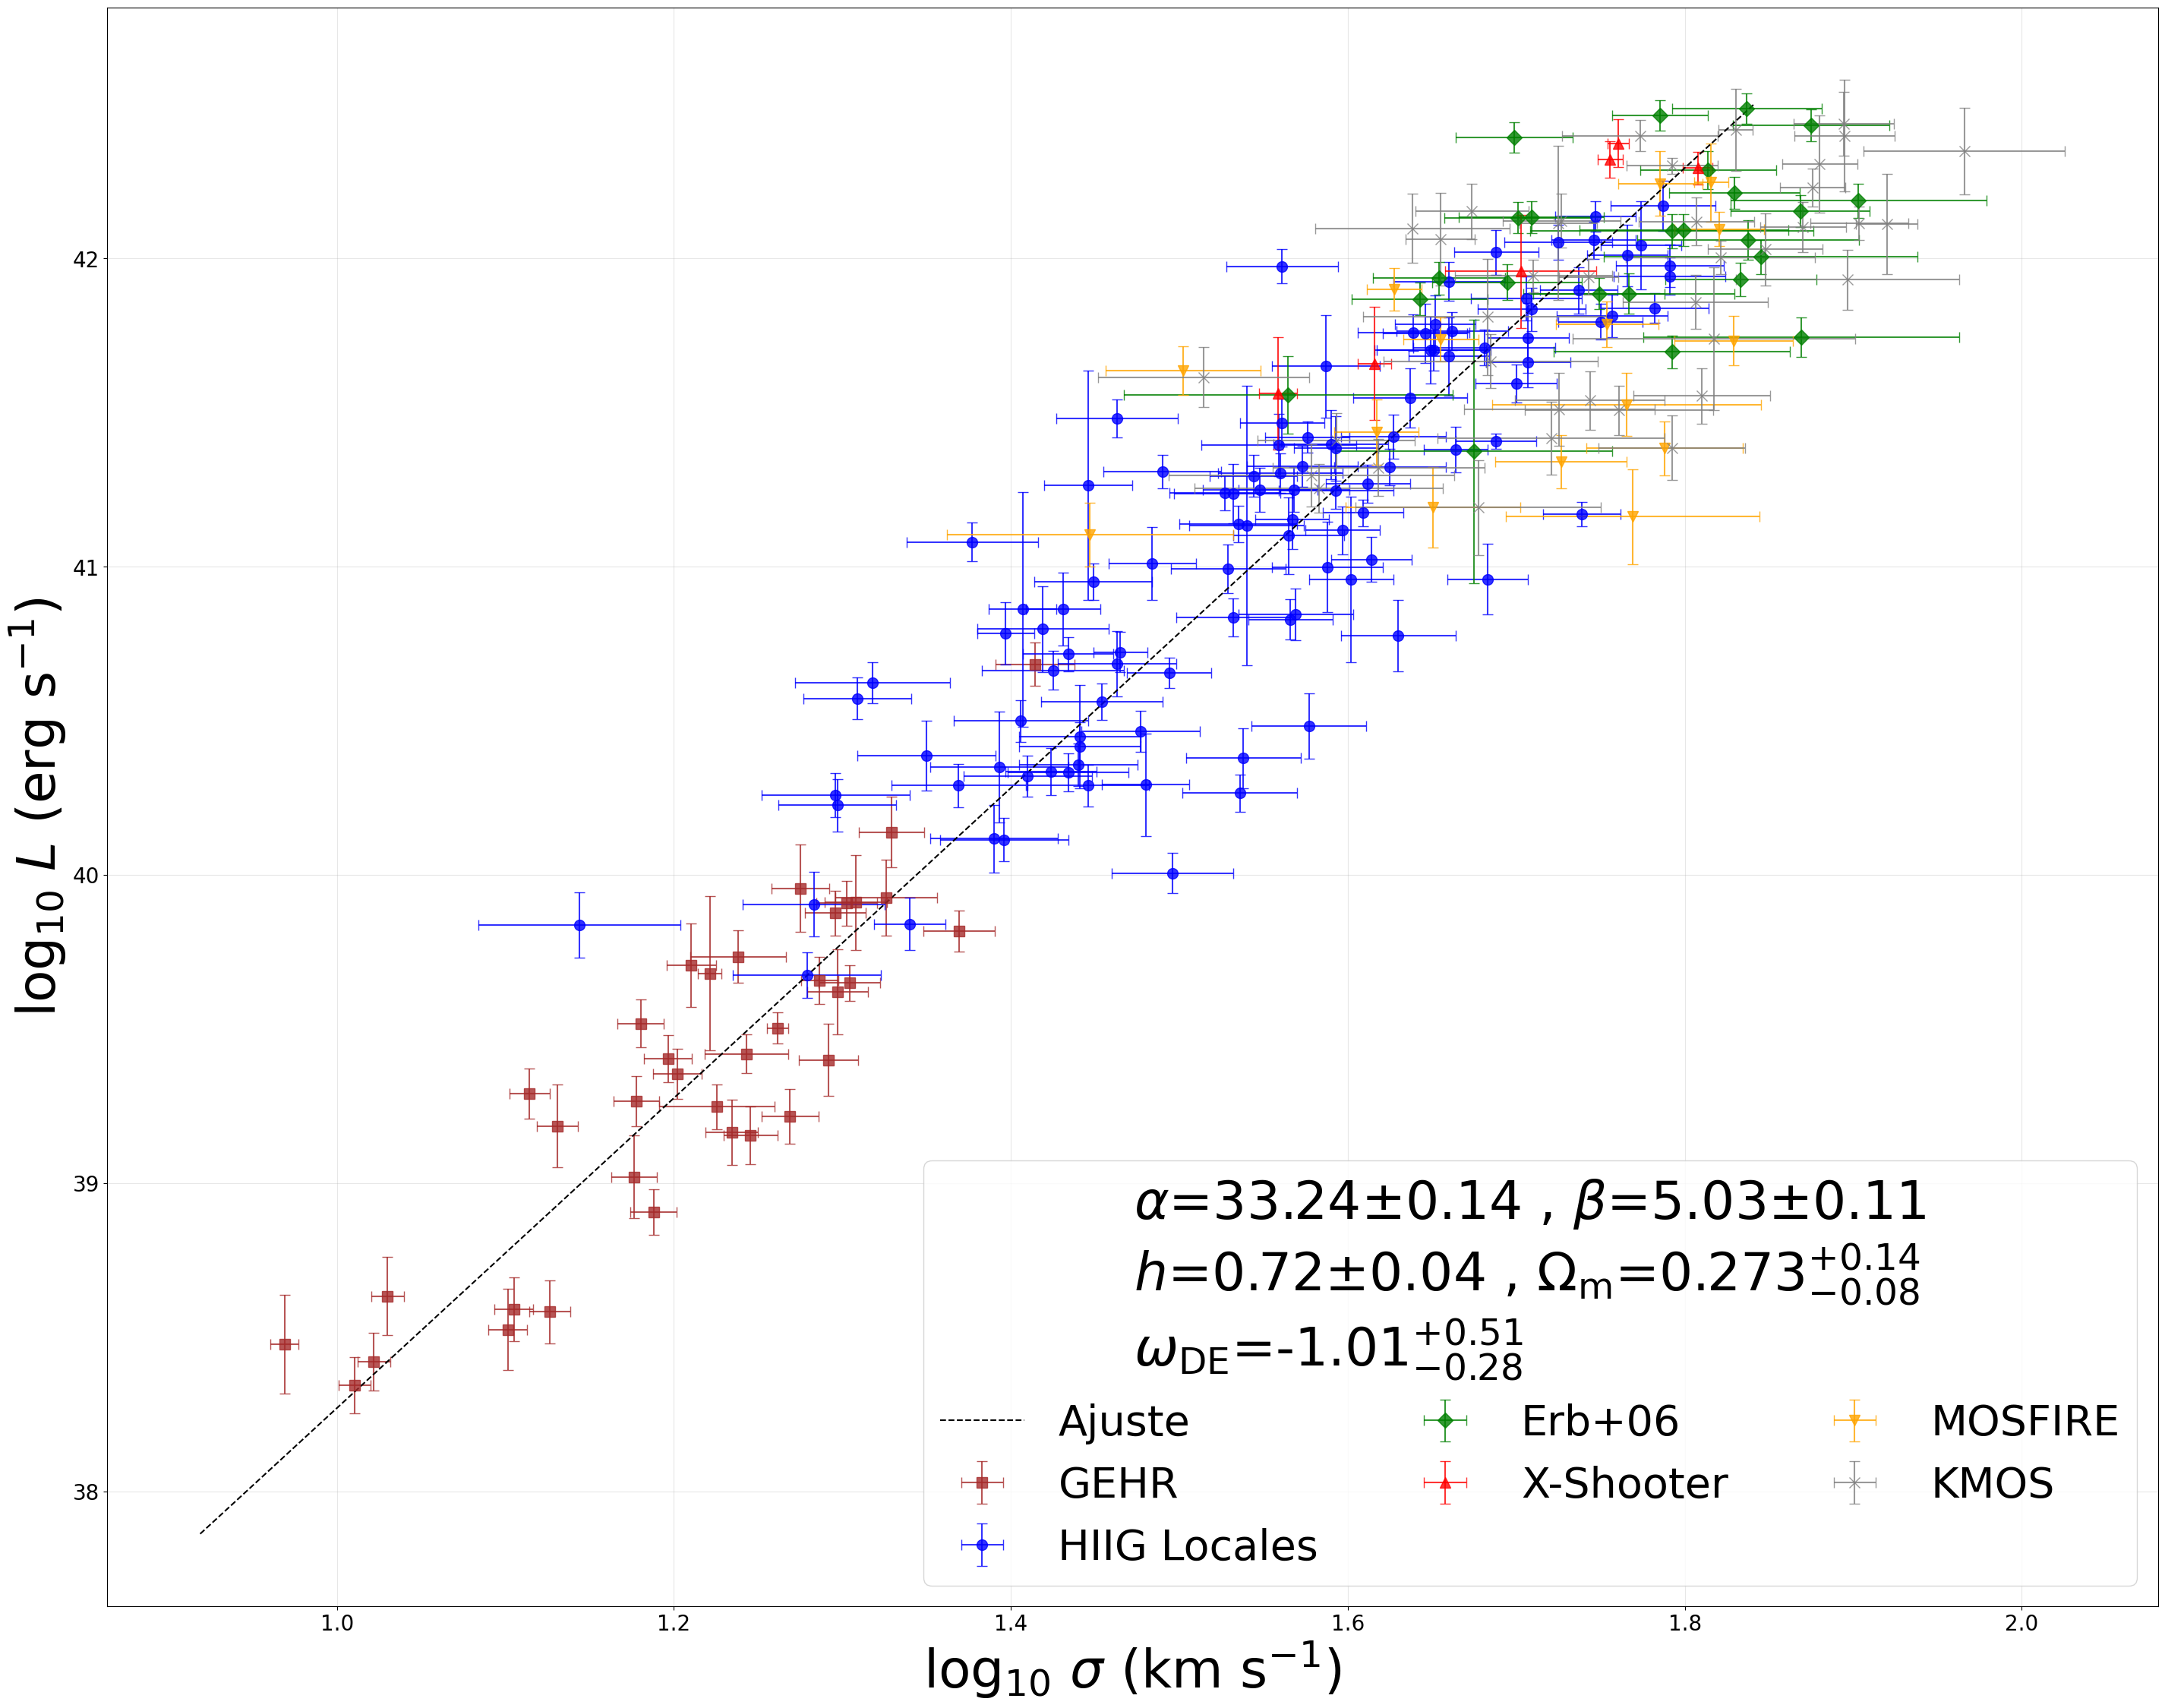

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(28.617329728, 22.592767987), dpi = 100)

samples = {
    0: "GEHR",
    1: "HIIG Locales",
    2: "Erb+06",
    3: "X-Shooter",
    4: "MOSFIRE",
    5: "KMOS",
}

markers = {0: "s", 1: "o", 2: "D", 3: "^", 4: "v", 5: "x"}
colors = {0: "brown", 1: "blue", 2: "green", 3: "red", 4: "orange", 5: "gray"}

for s, label in samples.items():
    m = flag == s
    if not np.any(m):
        continue
    ax.errorbar(
        log_sigma[m],
        logL[m],
        color = colors[s],
        xerr=err_logsig[m],
        yerr=err_logL[m],
        fmt=markers[s],
        linestyle="none",
        label=label,
        alpha=0.8,
        capsize=5,
        markersize=10
    )

ax.set_xlabel(r"$\log_{10}\, \sigma\ \mathrm{(km\ s^{-1})}$", fontsize = 50)
ax.set_ylabel(r"$\log_{10}\, L\ \mathrm{(erg\ s^{-1})}$", fontsize = 50)
ax.legend()
ax.grid(True, alpha=0.3)

#mask_fit = (flag == 0) | (flag == 1) | (flag == 2) | (flag == 3) | (flag == 4) | (flag == 5)
mask_fit = (flag == 0) | (flag == 1)


x = log_sigma[mask_fit]
y = logL[mask_fit]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

slope, intercept = 5.03 , 33.24 


# recta ajustada
x_line = np.linspace(x.min()-0.05, x.max()+0.05, 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, label=r"Ajuste", color = 'k', linestyle = '--')


ax.tick_params(axis='x', labelsize=20) # Changes x-axis tick label font size
ax.tick_params(axis='y', labelsize=20) 


ax.legend(ncol= 3,
          title=r"$\alpha$=33.24$\pm$0.14 , "  + 
          r"$\beta$=5.03$\pm$0.11" + "\n" + 
          r"$h$=0.72$\pm$0.04 , "  + 
          r"$\Omega_\text{m}$=0.273$^{+0.14}_{-0.08}$" + "\n" + 
          r"$\omega_\text{DE}$=-1.01$^{+0.51}_{-0.28}$",
          title_fontsize=50,
          fontsize = 40)


plt.tight_layout()
plt.show()


## Implementacion para HIIGs (3 primeros parámetros)

## $$\alpha , \beta , H_0 $$

In [ ]:
from __future__ import annotations
import os
import json
import numpy as np
from astropy.table import Table
from astropy.cosmology import FlatwCDM

import pymultinest
import matplotlib.pyplot as plt
import corner
from getdist import plots, MCSamples
import scipy.optimize as op

In [45]:
def lnlike(theta, x, y, z, xerr, yerr, zerr):
    alpha, beta, h0 = theta
    Om = 0.3
    w0 = -1.0
    cosmo = FlatwCDM(H0=h0*100, Om0=Om, w0=w0)

    ixG = np.where(z > 10)
    ixH = np.where(z < 10)

    Mum = z*0.0
    MumErr = z*0.0

    Mum[ixG] = z[ixG]
    MumErr[ixG] = zerr[ixG]
    Mum[ixH] = 5.0*np.log10(cosmo.luminosity_distance(z[ixH]).value) + 25.0
    MumErr[ixH] = (5.0/np.log(10.0))*(zerr[ixH]/z[ixH])

    Mu = 2.5*(beta*x + alpha) - 2.5*y - 100.195
    MuErr = 2.5*np.sqrt((yerr)**2 + beta**2*(xerr)**2)

    R = (Mu - Mum)
    W = 1.0/(MuErr**2 + MumErr**2)

    xsq = np.sum(R**2 * W)
    llq = -0.5*xsq
    return llq 

In [46]:
def load_data(dpath):
    Tpath = os.path.join(dpath, 'Union2020v16.dat')
    data = Table.read(Tpath, format='ascii', comment='#')

    vix  = np.asarray(data['col1'])
    vx   = np.asarray(data['col2'])
    vy   = np.asarray(data['col3'])
    vz   = np.asarray(data['col4'])
    vxEr = np.asarray(data['col5'])
    vyEr = np.asarray(data['col6'])
    vzEr = np.asarray(data['col7'])
    vsp  = np.asarray(data['col8'])


    return vix, vx, vy, vz, vxEr, vyEr, vzEr, vsp

In [47]:

def prior_transform(u):
    alpha = 20.0 + 20.0 * u[0]     # 20->40
    beta  =  0.0 + 10.0 * u[1]     # 0->10
    h0    =  0.5 +  0.5 * u[2]     # 0.5->1.0
    return np.array([alpha, beta, h0])

In [48]:
dpath = os.path.expanduser("~/HIIGalaxies/Bayesian_samplers/Multinest")

print("Data path:", dpath)

vTg, vx, vy, vz, vxErr, vyErr, vzErr, vsp = load_data(dpath)


Data path: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest


In [49]:

def nll(theta):
    return -lnlike(theta, vx, vy, vz, vxErr, vyErr, vzErr)

res = op.minimize(nll, x0=[32.0, 5.0, 0.75], method="Nelder-Mead")
print("ML guess:", res.x)

ML guess: [33.48268798  4.82632196  0.77453062]


In [50]:

outdir = os.path.join(dpath, "results_mnest")
os.makedirs(outdir, exist_ok=True)
prefix = os.path.join(outdir, "hii_")

def loglike_for_mnest(theta):
    return lnlike(theta, vx, vy, vz, vxErr, vyErr, vzErr)

In [51]:
n_dims = 3
result = pymultinest.solve(
    LogLikelihood=loglike_for_mnest,
    Prior=prior_transform,
    n_dims=n_dims,
    outputfiles_basename=prefix,
    evidence_tolerance=0.5,
    n_live_points=600,
    multimodal=True,
    verbose=True
)

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  600
 dimensionality =    3
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.998464
Replacements:                                650
Total Samples:                               651
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z):    -696.727189 +/-  0.999232
Acceptance Rate:                        0.990099
Replacements:                                700
Total Samples:                               707
Nested Sampling ln(Z):            -967846.796079
Importance Nested Sampling ln(Z):    -696.809710 +/-  0.999293
Acceptance Rate:                        0.979112
Replacements:                                750


In [52]:
print("\nEvidence lnZ = %.3f ± %.3f" % (result["logZ"], result["logZerr"]))


samples = result["samples"]   # shape = (Nsamples, 3)
parameters = [r"\alpha", r"\beta", r"h"]
print("Posterior means/stdev:")
for name, col in zip(parameters, samples.T):
    print(f"{name:>6s}: {col.mean():.3f} ± {col.std():.3f}")


with open(prefix + "params.json", "w") as f:
    json.dump(parameters, f, indent=2)

fig = corner.corner(
    samples,
    labels=[r"$\alpha$", r"$\beta$", r"$h$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84]
)
fig.savefig(prefix + "corner.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Corner guardado en:", prefix + "corner.png")


Evidence lnZ = -447.450 ± 0.136
Posterior means/stdev:
\alpha: 33.484 ± 0.105
 \beta: 4.824 ± 0.085
     h: 0.778 ± 0.039


Corner guardado en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/results_mnest/hii_corner.png


Removed no burn in
GetDist triangle en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/results_mnest/hii_triangle_getdist.png

Listo. Archivos en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/results_mnest


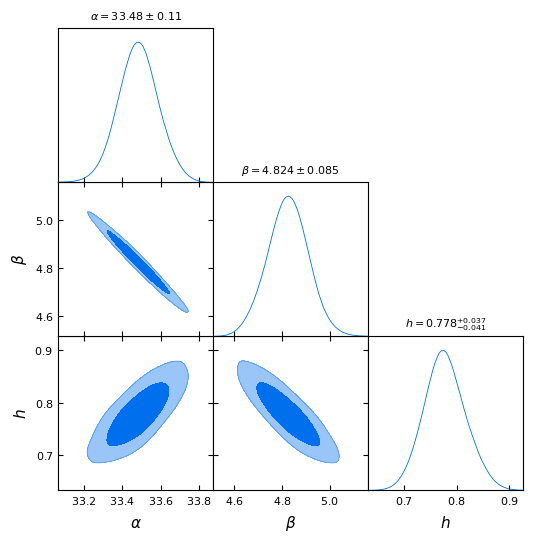

In [53]:

gds = MCSamples(
    samples=samples,
    names=["alpha", "beta", "h"],
    labels=[r"\alpha", r"\beta", r"h"]  
)
g = plots.getSubplotPlotter()
g.settings.num_plot_contours = 2
g.triangle_plot([gds], filled=True, title_limit=1)
g.export(prefix + "triangle_getdist.png")
print("GetDist triangle en:", prefix + "triangle_getdist.png")

print("\nListo. Archivos en:", outdir)

## Implementacion para HIIGs (5 parámetros)

## $$\alpha , \beta , H_0 , \Omega_{\text{m}} , w_{\text{DE}}$$

In [14]:
def lnlike(theta, x, y, z, xerr, yerr, zerr):
    alpha, beta, h0, Om, wDE = theta

    
    eps = 1e-6
    Om = np.clip(Om, eps, 1.0 - eps)
    h0 = float(h0)

    try:
        cosmo = FlatwCDM(H0=h0*100.0, Om0=Om, w0=wDE)
    except Exception:
        return -np.inf

    # índices
    ixG = (z >= 10)   
    ixH = (z <  10)

    Mum = np.zeros_like(z, dtype=float)
    MumErr = np.zeros_like(z, dtype=float)

    
    Mum[ixG] = z[ixG]
    MumErr[ixG] = zerr[ixG]

   
    zz = z[ixH]
    zzerr = zerr[ixH]
   
   
    if np.any(zz <= 0):
        return -np.inf

    try:
        DL = cosmo.luminosity_distance(zz).value  # Mpc
        if not np.all(np.isfinite(DL)) or np.any(DL <= 0):
            return -np.inf
        Mum[ixH] = 5.0*np.log10(DL) + 25.0
        MumErr[ixH] = (5.0/np.log(10.0))*(zzerr/zz)
    except Exception:
        return -np.inf

    Mu = 2.5*(beta*x + alpha) - 2.5*y - 100.195
    MuErr = 2.5*np.sqrt(yerr**2 + (beta**2)*(xerr**2))

    
    var = MuErr**2 + MumErr**2
    if np.any(var <= 0) or not np.all(np.isfinite(var)):
        return -np.inf

    R = Mu - Mum
    if not np.all(np.isfinite(R)):
        return -np.inf

    xsq = np.sum((R**2)/var)
    if not np.isfinite(xsq):
        return -np.inf

    return -0.5*xsq

In [15]:
def load_data(dpath):
    Tpath = os.path.join(dpath, 'indat/Union2020v16.dat')
    data = Table.read(Tpath, format='ascii', comment='#')

    vix  = np.asarray(data['col1'])
    vx   = np.asarray(data['col2'])
    vy   = np.asarray(data['col3'])
    vz   = np.asarray(data['col4'])
    vxEr = np.asarray(data['col5'])
    vyEr = np.asarray(data['col6'])
    vzEr = np.asarray(data['col7'])
    vsp  = np.asarray(data['col8'])

    LSL = 1.83
    ix = np.where((vx - vxEr) <= LSL)
    return vix[ix], vx[ix], vy[ix], vz[ix], vxEr[ix], vyEr[ix], vzEr[ix], vsp[ix]



In [16]:

def prior_transform(u):
    alpha = 20.0 + 20.0 * u[0]     # 2->40
    beta  =  0.0 + 10.0 * u[1]     # 0->0
    h0    =  0.5 +  0.5 * u[2]     # 0.5->1.0
    Om    =  0.0 +  1.0 * u[3]
    wDE   = -2.0 +  3.0 * u[4]
    return np.array([alpha, beta, h0, Om, wDE])

In [17]:
HOME = os.path.expanduser("~") + '/HIIGs/'
dpath = os.path.join(HOME, "MCMC/ZEUS/h0wsh2023/dat/")

dpath = '/home/holman//MCMC/ZEUS/h0wsh2023/dat/'
print("Data path:", dpath)

vTg, vx, vy, vz, vxErr, vyErr, vzErr, vsp = load_data(dpath)

Data path: /home/holman//MCMC/ZEUS/h0wsh2023/dat/


In [18]:

outdir = os.path.join(dpath, "results_5nestHII")
os.makedirs(outdir, exist_ok=True)
prefix = os.path.join(outdir, "hii_")

def loglike_for_mnest(theta):
    return lnlike(theta, vx, vy, vz, vxErr, vyErr, vzErr)

In [19]:
n_dims = 5
result = pymultinest.solve(
    LogLikelihood=loglike_for_mnest,
    Prior=prior_transform,
    n_dims=n_dims,
    outputfiles_basename=prefix,
    evidence_tolerance=0.5,
    n_live_points=600,
    multimodal=True,
    verbose=True
)

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  600
 dimensionality =    5
 *****************************************************
 Starting MultiNest
 generating live points


 live points generated, starting sampling
Acceptance Rate:                        0.993884
Replacements:                                650
Total Samples:                               654
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z):    -473.077502 +/-  0.999235
Acceptance Rate:                        0.985915
Replacements:                                700
Total Samples:                               710
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z):    -473.159659 +/-  0.999296
Acceptance Rate:                        0.975293
Replacements:                                750
Total Samples:                               769
Nested Sampling ln(Z):            -723935.410924
Importance Nested Sampling ln(Z):    -473.239485 +/-  0.999350
Acceptance Rate:                        0.963855
Replacements:                                800
Total Samples:                               830
Nested Sampling ln(Z):            

In [20]:
print("\nEvidence lnZ = %.3f ± %.3f" % (result["logZ"], result["logZerr"]))

samples = result["samples"]   # shape = (Nsamples, 5)
parameters = [r"\alpha", r"\beta", r"h",r"\Omega_m",r"w_{DE}"]
print("Posterior means/stdev:")
for name, col in zip(parameters, samples.T):
    print(f"{name:>6s}: {col.mean():.3f} ± {col.std():.3f}")

# Guarda nombres para scripts auxiliares
with open(prefix + "params.json", "w") as f:
    json.dump(parameters, f, indent=2)


fig = corner.corner(
    samples,
    labels=[r"$\alpha$", r"$\beta$", r"$h$",r"\Omega_m",r"w_{DE}"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84]
)
fig.savefig(prefix + "corner.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Corner guardado en:", prefix + "corner.png")


Evidence lnZ = -407.389 ± 0.146
Posterior means/stdev:
\alpha: 33.231 ± 0.139
 \beta: 5.034 ± 0.114
     h: 0.718 ± 0.040
\Omega_m: 0.271 ± 0.112
w_{DE}: -0.997 ± 0.406
Corner guardado en: /home/holman//MCMC/ZEUS/h0wsh2023/dat/results_5nestHII/hii_corner.png


Removed no burn in
GetDist triangle en: /home/holman//MCMC/ZEUS/h0wsh2023/dat/results_5nestHII/hii_triangle_getdist.png

Listo. Archivos en: /home/holman//MCMC/ZEUS/h0wsh2023/dat/results_5nestHII


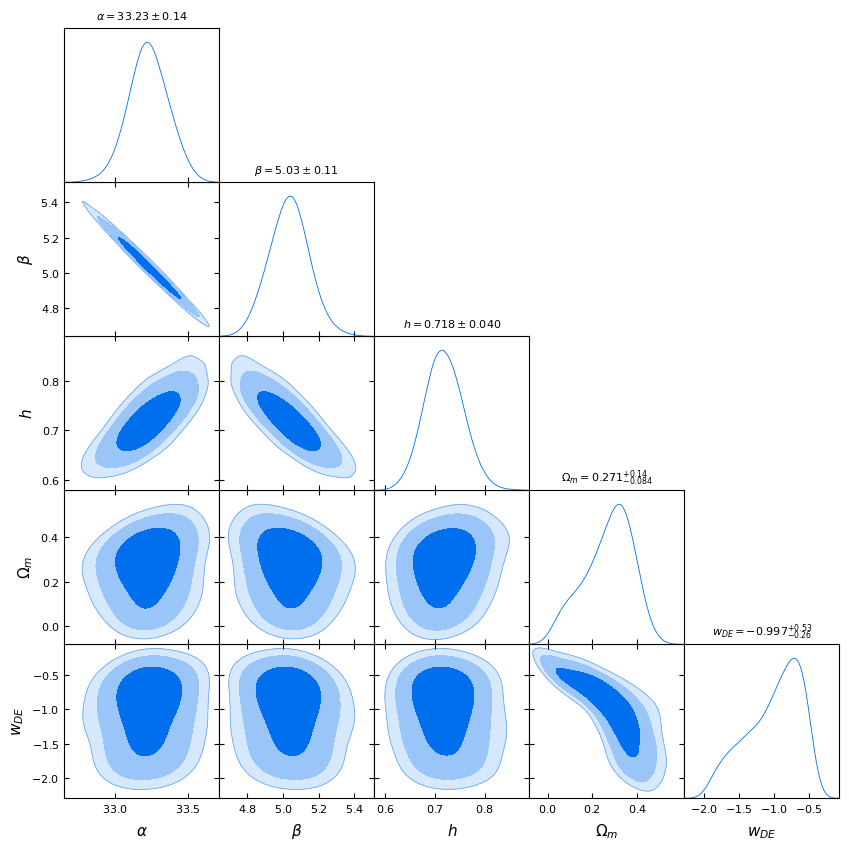

In [21]:
gds = MCSamples(
    samples=samples,
    names=["alpha", "beta", "h","Om","wDE"],
    labels=[r"\alpha", r"\beta", r"h",r"\Omega_m",r"w_{DE}"]  # SIN '$', GetDist los añade
)
g = plots.getSubplotPlotter()
g.settings.num_plot_contours = 3
g.triangle_plot([gds], filled=True, title_limit=1)
g.export(prefix + "triangle_getdist.png")
print("GetDist triangle en:", prefix + "triangle_getdist.png")

print("\nListo. Archivos en:", outdir)